In [2]:
%load_ext autoreload
%autoreload 2

import sys

PROJECT = "/Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update"

sys.path.insert(0, PROJECT)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from skfda import FDataGrid
from skfda.exploratory.depth import IntegratedDepth, ModifiedBandDepth

from matplotlib_scalebar.scalebar import ScaleBar

from src import loader, plotter

from src.config import DATA, DEPTH, IMAGES, VALIDATION, TABLES
from src.fda import _fDepth, _fQuantile
from src.utils import KS, get_band_fraction, get_hyper, mask_intervals

from src.fdu import functional_dynamic_update

# Loading color palette
palette_ = pd.read_csv(DATA / "palette.csv")

# Loading Texas map
_TX = gpd.read_file(DATA / "maps/TX/State.shp")

T = 288
method = "fusion"
resource = "wind"
aggregation = "asset"

# Update seasonal and spatial distance with similarity metric and lambda parameters
# kappa_0 to the code first neighborhood threshold
# Remove xi and gamma

# Load Data

In [3]:
(
    F_tr_,
    F_ts_,
    E_tr_,
    E_ts_,
    X_tr_,
    X_ts_,
    T_tr_,
    T_ts_,
    assets_tr_,
    assets_ts_,
    t_tr_,
    t_ts_,
    dt_,
    dx_,
) = loader.preprocessed_dataset(
    unbiased = True,
    path_to_training_data = DATA / "preprocessed_wind_2017.pkl",
    path_to_testing_data = DATA / "preprocessed_wind_2018.pkl",
    T = 288,
)

print(F_tr_.shape, F_ts_.shape)
print(E_tr_.shape, E_ts_.shape)
print(X_tr_.shape, X_ts_.shape)
print(T_tr_.shape, T_ts_.shape)
print(assets_tr_.shape, assets_ts_.shape)
print(t_tr_.shape, t_ts_.shape)
print(dt_.shape, dx_.shape)

E_tr_lin_, E_ts_lin_ = loader.processed_dataset(
    unbiased = True,
    path_to_training_data = DATA / "linear_preprocessed_wind_2017.pkl",
    path_to_testing_data = DATA / "linear_preprocessed_wind_2018.pkl",
    T = 288,
)

print(E_tr_lin_.shape, E_ts_lin_.shape)

E_tr_biased_, E_ts_biased_ = loader.processed_dataset(
    unbiased = False,
    path_to_training_data = DATA / "preprocessed_wind_2017.pkl",
    path_to_testing_data = DATA / "preprocessed_wind_2018.pkl",
    T = 288,
)

print(E_tr_biased_.shape, E_ts_biased_.shape)

(67881, 288) (364, 288, 187)
(67881, 288) (364, 288, 187)
(67881, 2) (187, 2)
(67881, 288) (364, 288)
(67881, 1) (187,)
(67881,) (364,)
(288,) (288,)
(67881, 288) (364, 288, 187)
(67881, 288) (364, 288, 187)


In [86]:
# wind unbiased-025 {72: 1, 144: 4, 216: 1}
# wind biased-025 {72: 2, 144: 1, 216: 2}
exp_description="unbiased-025"
_init = {72: 1, 144: 3, 216: 4}

# exp_description="biased-025"
# _init = {72: 5, 144: 2, 216: 1}

hyper_, envelope_ = loader.hyperparameters(
    _init,
    resource,
    method,
    aggregation,
    exp_description,
    path_to_validation = VALIDATION,
)

hyper_.loc['length_scale_f'] = 1./hyper_.loc['tau']
hyper_.loc['length_scale_e'] = hyper_.loc['length_scale_f']*hyper_.loc['rho_e']
hyper_.loc['length_scale_d'] = hyper_.loc['length_scale_f']*hyper_.loc['rho_d']
print(hyper_)
# print(envelope_)

stats_, funcs_ = loader.get_asset_stats(
    _init, 
    resource, 
    method, 
    aggregation, 
    exp_description, 
    T, 
    VALIDATION, 
)
# print(stats_)
# print(funcs_)

time                    72           144          216
p_fusion           0.750000     0.750000     0.750000
forget_rate_f      0.125000     0.125000     0.125000
forget_rate_e      1.000000     1.000000     1.000000
lookahead_rate     4.000000     4.000000     4.000000
tau                0.001000     0.001000     0.001000
kappa            150.000000   150.000000   150.000000
rho_e              0.302736     0.069038     0.078308
rho_d              0.007216     0.000651     0.000343
kappa_0          150.000000  1881.000000   150.000000
nu                 2.000000     4.000000     7.000000
sigma              0.152358     0.185214     0.074519
length_scale_f  1000.000000  1000.000000  1000.000000
length_scale_e   302.736162    69.038462    78.307943
length_scale_d     7.216120     0.651331     0.342695


In [87]:
df_fmt, latex = loader.error_scores(
    _init,
    resource, 
    method,
    aggregation,
    exp_description,
    VALIDATION)
print(latex)

df_fmt, latex = loader.envelope_scores(
    envelope_, 
    alphas = [0.1, 0.2]
)
print(latex)

\begin{table}
\caption{Forecast error metrics by lead time and distance method.}
\label{tab:error_metrics}
\begin{tabular}{clccc}
\toprule
 &  & RMSE & MAE & MBE \\
Forecast Update Time $\tau$ & Estimator &  &  &  \\
\midrule
\multirow[c]{3}{*}{72} & nan & 0.1321 & 0.0993 & 0.0022 \\
 & $\hat{\mu}_{deep}(s)$ & 0.1418 & 0.1066 & 0.0025 \\
 & $\hat{\mu}_{focal}(s)$ & 0.1319 & 0.1022 & -0.0033 \\
\multirow[c]{3}{*}{144} & nan & 0.1420 & 0.1089 & -0.0011 \\
 & $\hat{\mu}_{deep}(s)$ & 0.1571 & 0.1209 & -0.0037 \\
 & $\hat{\mu}_{focal}(s)$ & 0.1443 & 0.1141 & -0.0026 \\
\multirow[c]{3}{*}{216} & nan & 0.1413 & 0.1178 & -0.0046 \\
 & $\hat{\mu}_{deep}(s)$ & 0.1445 & 0.1203 & -0.0044 \\
 & $\hat{\mu}_{focal}(s)$ & 0.1407 & 0.1199 & -0.0030 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Forecast error metrics by update time and estimator.}
\label{tab:error_metrics}
\begin{tabular}{clccccccccccccccc}
\toprule
 &   & \multicolumn{5}{c}{FIS} & \multicolumn{5}{c}{FCS} & \multicolu

In [5]:
# The same region, different day, for a given interval (eg, 144), low and high scores.
interval = 144   # or "144" if your columns are strings
df_score = stats_.copy()
df_funcs = funcs_.copy()

df_score = df_score.loc[
    ((df_funcs[interval] < .75 ) & (df_funcs[interval] > .25 ))
].reset_index(drop = True)

# Lowest score day for each region
idx_low = df_score.groupby("region")[interval].idxmin()
low_df = df_score.loc[idx_low].rename(
    columns={"day": "low_day", interval: "low_score"}
)
low_df = low_df[["region", "low_day", "low_score"]]
print(low_df.shape)

# Highest score day for each region
idx_high = df_score.groupby("region")[interval].idxmax()

high_df = df_score.loc[idx_high].rename(
    columns={"day": "high_day", interval: "high_score"}
)
high_df = high_df[["region", "high_day", "high_score"]]
print(high_df.shape)

summary = low_df.merge(high_df, on="region")
summary["difference"] = summary["high_score"] - summary["low_score"]
summary = summary.sort_values("region", ascending=False).reset_index(drop=True)
print(summary)

(10, 3)
(10, 3)
   region  low_day  low_score  high_day  high_score  difference
0      19      266   0.194811        30    0.366145    0.171333
1      18      112   0.163457        46    0.351416    0.187959
2      17      141   0.140651        92    0.333261    0.192610
3      16       23   0.165471         6    0.377194    0.211722
4      15      212   0.180584       312    0.351917    0.171333
5      14      229   0.214801       359    0.363617    0.148816
6      13      205   0.157392        63    0.350885    0.193493
7      12       99   0.207741       139    0.371582    0.163840
8      11      226   0.160920       186    0.371468    0.210547
9      10      170   0.166093        54    0.336297    0.170204


In [6]:
# The same region, same day, growing scores across intervals (72, 144, 216).
df_score = stats_.copy()
df_funcs = funcs_.copy()
intervals_ = keys = list(_init.keys())

df_score = df_score.loc[
    ((df_funcs[interval] < .75 ) & (df_funcs[interval] > .25 ))
].reset_index(drop = True)

# Strictly decreasing score
growing_df = df_score[
    ((df_score[intervals_[0]] >= df_score[intervals_[1]]) 
    & (df_score[intervals_[1]] >= df_score[intervals_[2]]))
].copy()

growing_df["increase_1"] = growing_df[intervals_[0]] - growing_df[intervals_[1]]
growing_df["increase_2"] = growing_df[intervals_[1]] - growing_df[intervals_[2]]
growing_df["increase"]   = growing_df[["increase_1", "increase_2"]].min(axis=1)

growing_df = growing_df.sort_values("increase", ascending=False).reset_index(drop=True)

print(growing_df)

     region  day        72       144       216  increase_1  increase_2  \
0        12  348  0.346052  0.261679  0.145525    0.084373    0.116154   
1        13   13  0.345205  0.269994  0.188801    0.075211    0.081192   
2        16  318  0.359558  0.291557  0.215228    0.068001    0.076329   
3        13  356  0.343585  0.280940  0.191942    0.062645    0.088998   
4        18   22  0.281538  0.219271  0.149485    0.062267    0.069787   
..      ...  ...       ...       ...       ...         ...         ...   
341      17   40  0.240508  0.211084  0.210942    0.029424    0.000141   
342      15   86  0.285715  0.285612  0.214938    0.000103    0.070674   
343      14   96  0.231229  0.231201  0.209604    0.000028    0.021596   
344      19  232  0.213019  0.213011  0.203786    0.000009    0.009225   
345      19  329  0.256048  0.197061  0.197056    0.058988    0.000005   

     increase  
0    0.084373  
1    0.075211  
2    0.068001  
3    0.062645  
4    0.062267  
..        ...  

In [7]:
# # Two regions, same day, low and high scores for the same interval (eg, 144).
# df_score = stats_.copy()
# interval = intervals_[0]

# # Lowest-score region for each day
# idx_low = df_score.groupby("day")[interval].idxmin()

# # Highest-score region for each day
# idx_high = df_score.groupby("day")[interval].idxmax()

# low_df = df_score.loc[idx_low].rename(columns={"region": "low_region", interval: "low_score"})
# low_df = low_df[["day", "low_region", "low_score"]]

# high_df = df_score.loc[idx_high].rename(columns={"region": "high_region", interval: "high_score"})
# high_df = high_df[["day", "high_region", "high_score"]]

# summary = low_df.merge(high_df, on="day")
# summary["difference"] = summary["high_score"] - summary["low_score"]
# summary = summary.sort_values("difference", ascending=False).reset_index(drop=True)
# print(summary)

# Functional kNNs dynamic update

0.6763929317860214 111.8790931395223
Blue Summit 2018-07-15 12:00:00
[0 1 2] [ 262 1570   49]
wind-19-195-144-asset


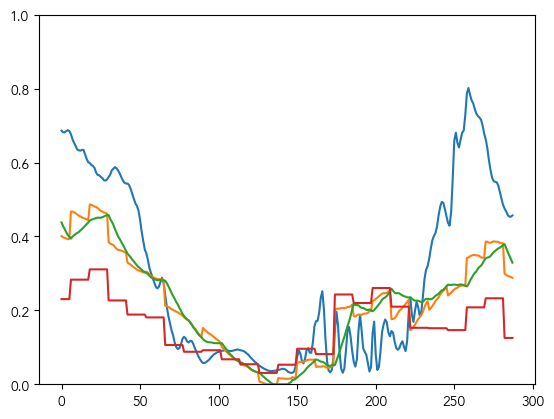

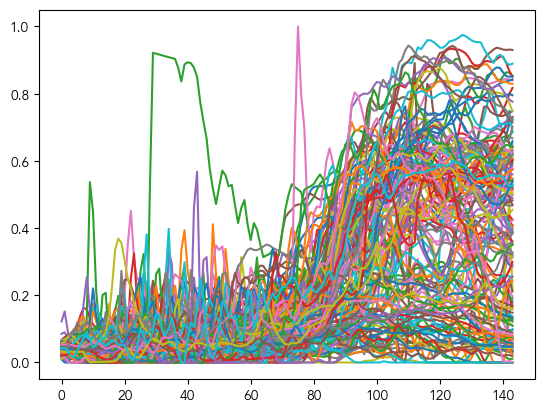

In [80]:
# Blue Summit 2018-01-06 12:00:00
# [0 1 2] [ 165 1838   16] 0.32089993194505706
# (2019,) (67881,) (2019,) (150,)

day = 195
asset = 19               
interval = 144

_fdu = functional_dynamic_update(
    _distances = {"temporal": "seasonal_equinox", 
                  "spatial": "haversine", 
                  "fusion": "dynamic"},
    name = assets_ts_[asset],
    date = T_ts_[day, interval],
)

# Filter solar hours with loading solar set
interval_mask = mask_intervals(
    F_tr_, 
    E_tr_biased_, 
    t_tr_, 
    day, 
    day_window = 7,
)

_fdu.fit(
    F_tr_,
    E_tr_lin_,
    dt_,
    X_ = X_tr_,
    t_ = t_tr_,
    interval_mask = interval_mask,
    n_samples_per_hour = 12,
)
M_ = _fdu.predict(
    F_ts_[day, :interval, asset], 
    E_ts_lin_[day, :, asset], 
    X_ts_[asset, :], 
    t_ts_[day],
    forget_rate_f = get_hyper(hyper_, "forget_rate_f", interval),
    forget_rate_e = get_hyper(hyper_, "forget_rate_e", interval),
    lookahead_rate = get_hyper(hyper_, "lookahead_rate", interval),
    length_scale_f = get_hyper(hyper_, "length_scale_f", interval),
    length_scale_e = get_hyper(hyper_, "length_scale_e", interval),
    length_scale_d = get_hyper(hyper_, "length_scale_d", interval),
    sigma = get_hyper(hyper_, "sigma", interval),
    nu = get_hyper(hyper_, "nu", interval),
    kappa_0 = get_hyper(hyper_, "kappa_0", interval),
    kappa = get_hyper(hyper_, "kappa", interval),
    p_fusion = get_hyper(hyper_, "p_fusion", interval),
)
# print(_fdu.idx_fed_)
# print(_fdu.idx_x_.shape)
print(np.exp(_fdu.xi), _fdu.r)
x_, y_ = np.unique(_fdu.arg_fed_[_fdu.idx_fed_], return_counts=True)
print(_fdu.name, _fdu.date)
print(x_, y_)

# Plotting variables
e_biased_ = E_ts_biased_[day, :, asset]
f_hat_ = F_ts_[day, interval:, asset]
e_lin_ = E_ts_lin_[day, :, asset]
x_ts_ = X_ts_[asset, :]
e_ = E_ts_[day, :, asset]
f_ = F_ts_[day, :interval, asset]

file_name = f"{resource}-{asset}-{day}-{interval}-asset"
print(file_name)

plt.figure()
plt.plot(F_ts_[day, :, asset])
plt.plot(e_)
plt.plot(e_lin_)
plt.plot(e_biased_)
plt.ylim(0, 1)
plt.show()

plt.figure()
plt.plot(M_.T)
plt.show()

10 167
[0 1 2] [  84 1674  261] 0.24189848942592115
(2019,) (67881,) (2019,) (150,)


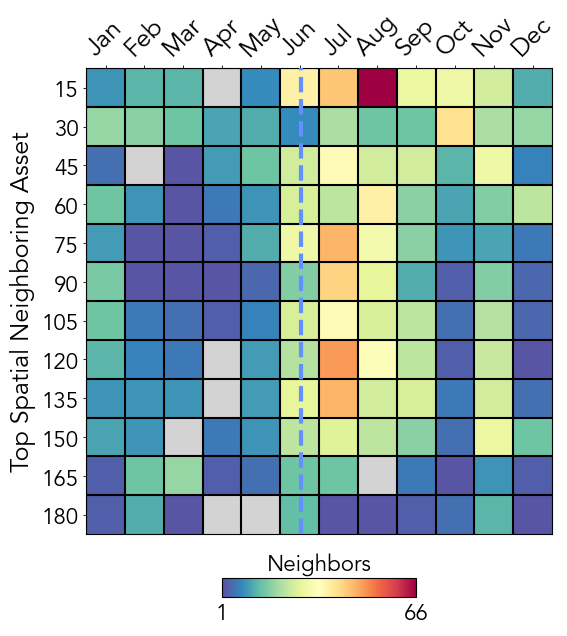

10 335
[0 1 2] [  44 1781  194] 0.21446519288382782
(2019,) (67881,) (2019,) (150,)


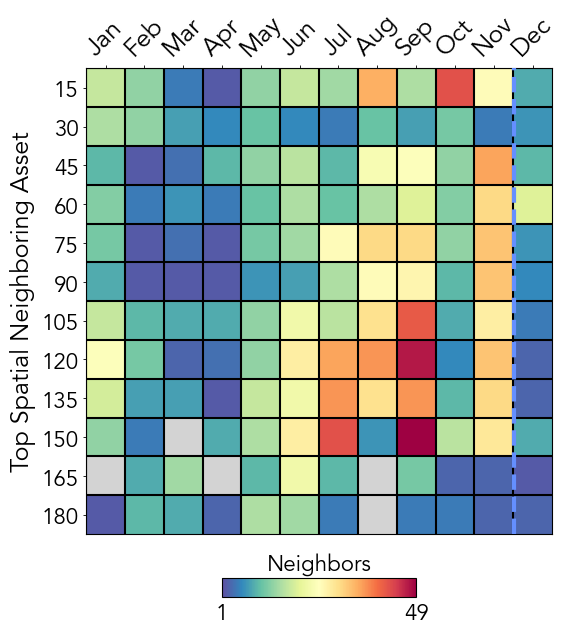

10 337
[0 1 2] [  40 1468  511] 0.2018679032365664
(2019,) (67881,) (2019,) (150,)


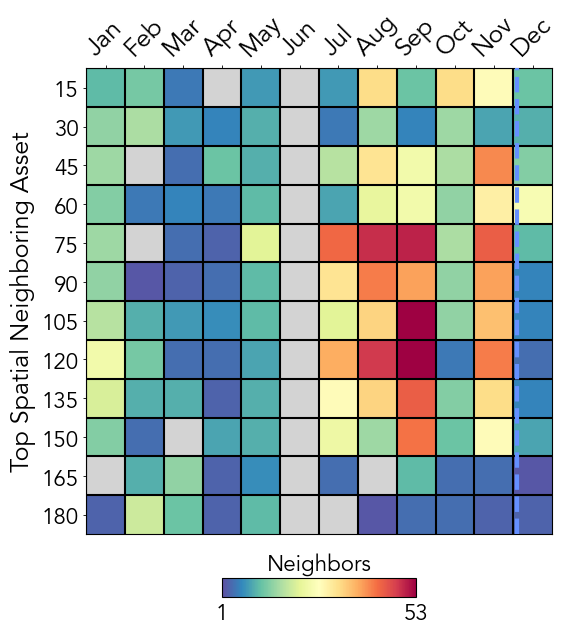

10 357
[0 1 2] [  75 1791  153] 0.24999885149477685
(2019,) (67881,) (2019,) (150,)


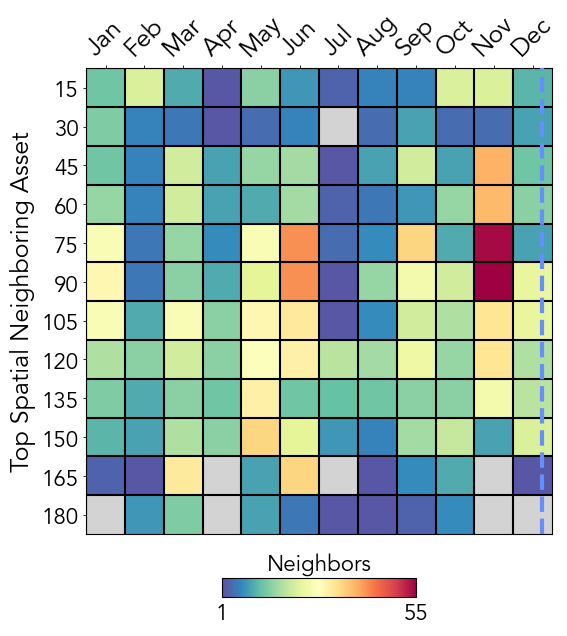

11 7
[0 1 2] [ 315 1304  400] 0.23031380681125788
(2019,) (67881,) (2019,) (150,)


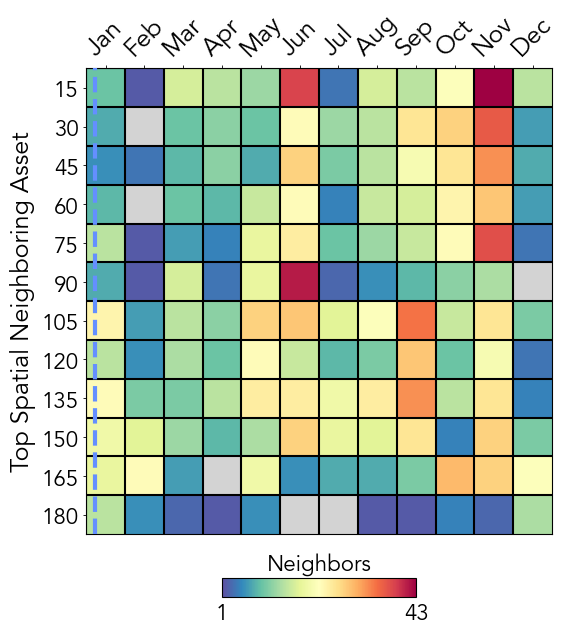

11 23
[0 1 2] [  44 1453  522] 0.22854201435942678
(2019,) (67881,) (2019,) (150,)


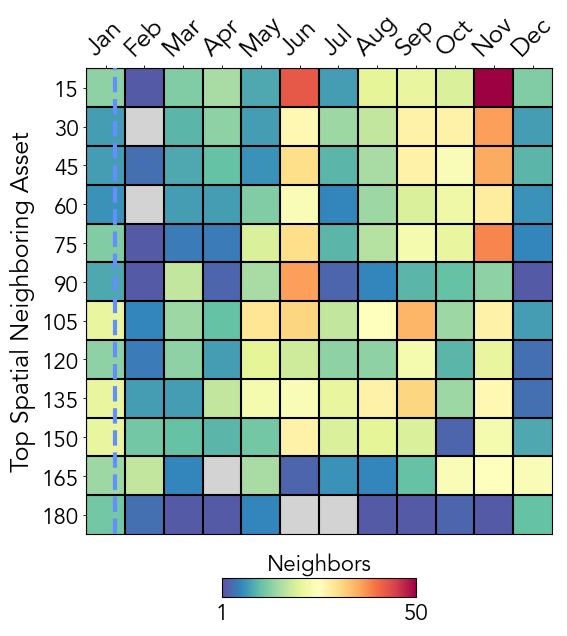

11 208
[0 1 2] [  30 1817  172] 0.2006213157653705
(2019,) (67881,) (2019,) (150,)


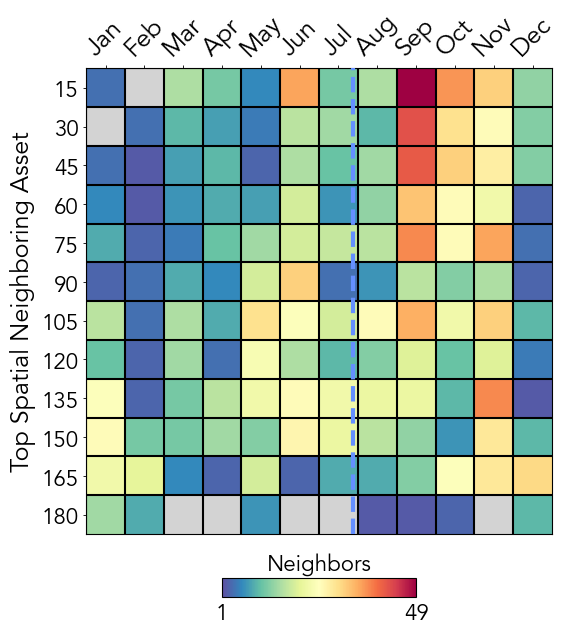

11 224
[0 1 2] [  55 1705  259] 0.2262490797867618
(2019,) (67881,) (2019,) (150,)


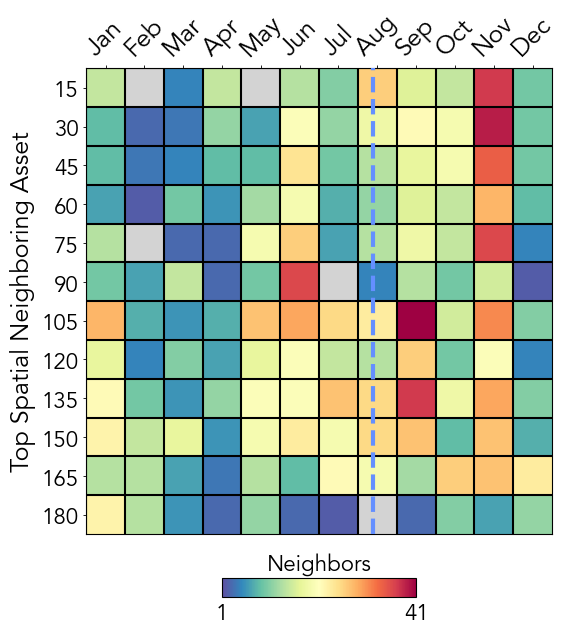

11 319
[0 1 2] [  47 1817  155] 0.23574719456941942
(2019,) (67881,) (2019,) (150,)


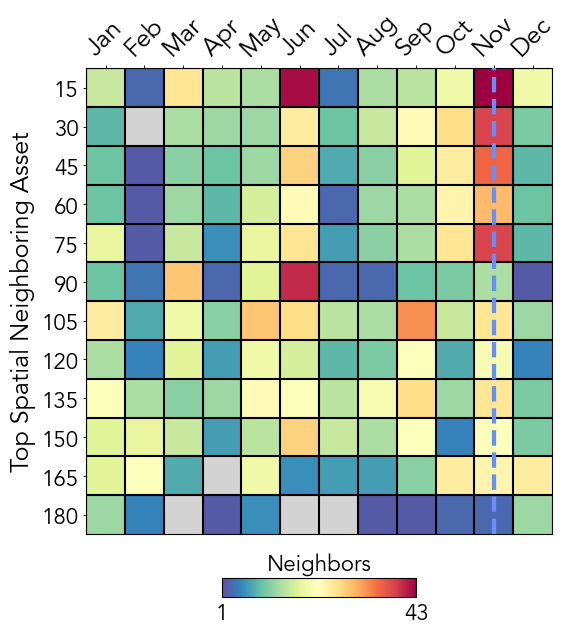

11 340
[0 1 2] [ 553 1188  278] 0.2447422091339357
(2019,) (67881,) (2019,) (150,)


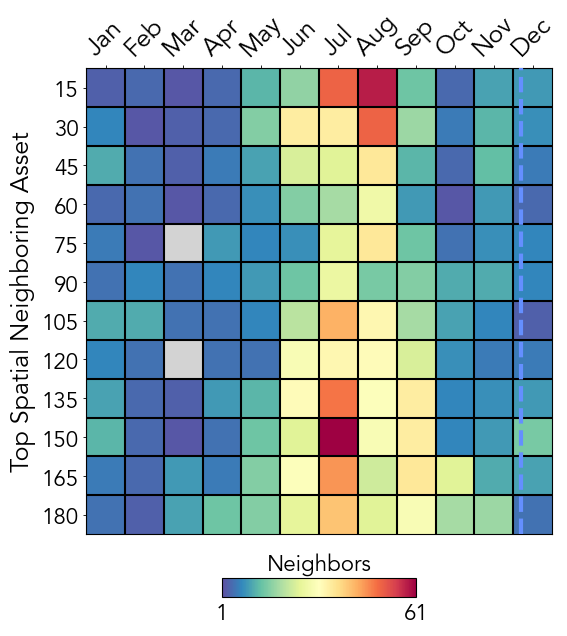

12 23
[0 1 2] [  45 1599  375] 0.21383499865518202
(2019,) (67881,) (2019,) (150,)


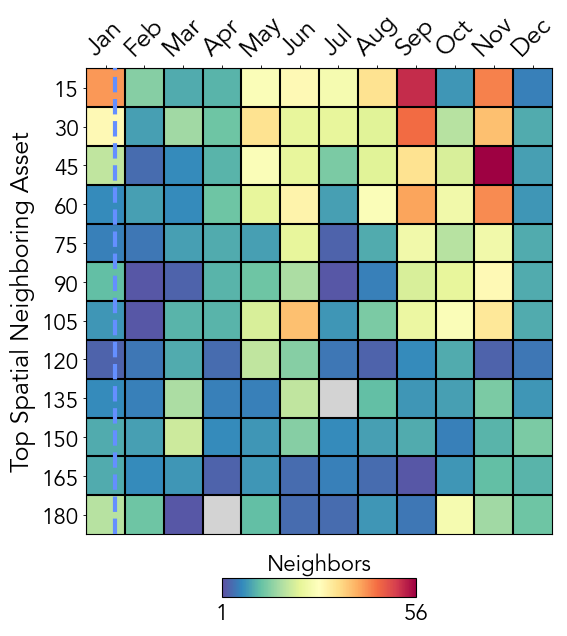

12 43
[0 1 2] [ 675 1051  293] 0.20135655097779911
(2019,) (67881,) (2019,) (150,)


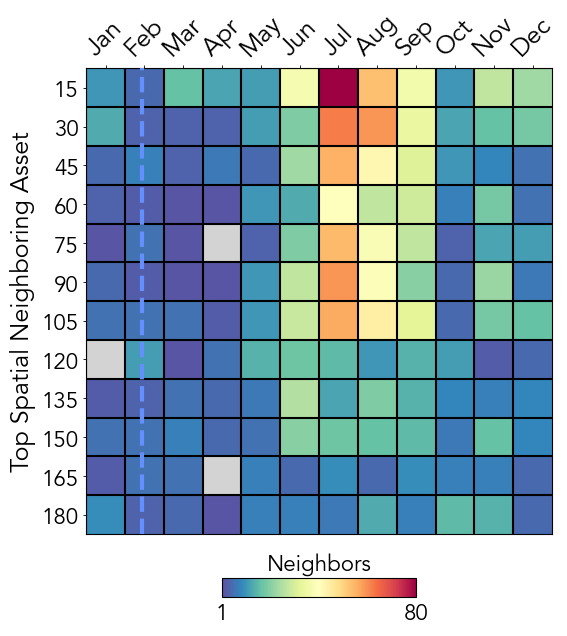

12 115
[0 1 2] [  57 1797  165] 0.21136200604965555
(2019,) (67881,) (2019,) (150,)


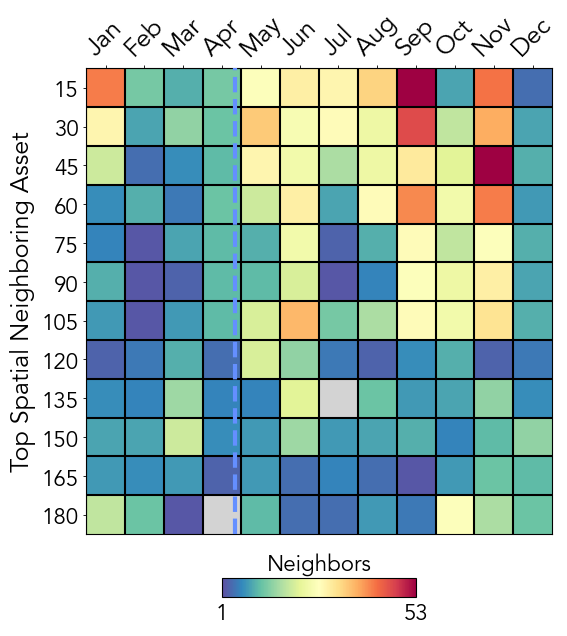

12 182
[0 1 2] [  78 1662  279] 0.2369819750805513
(2019,) (67881,) (2019,) (150,)


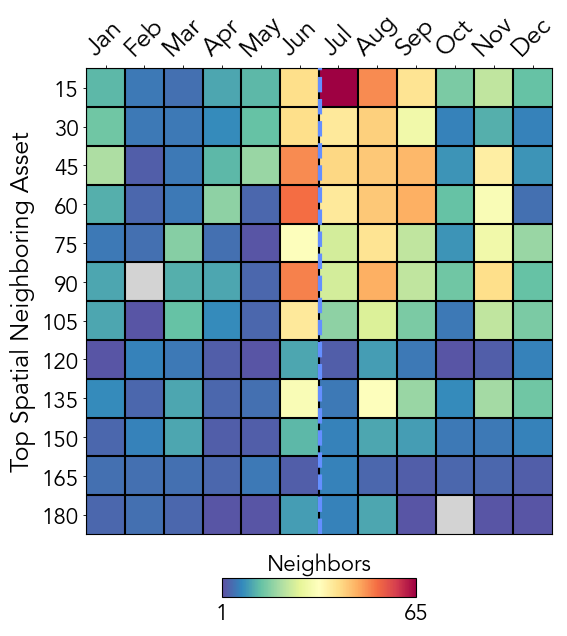

12 183
[0 1 2] [  80 1423  516] 0.2659293362246281
(2019,) (67881,) (2019,) (150,)


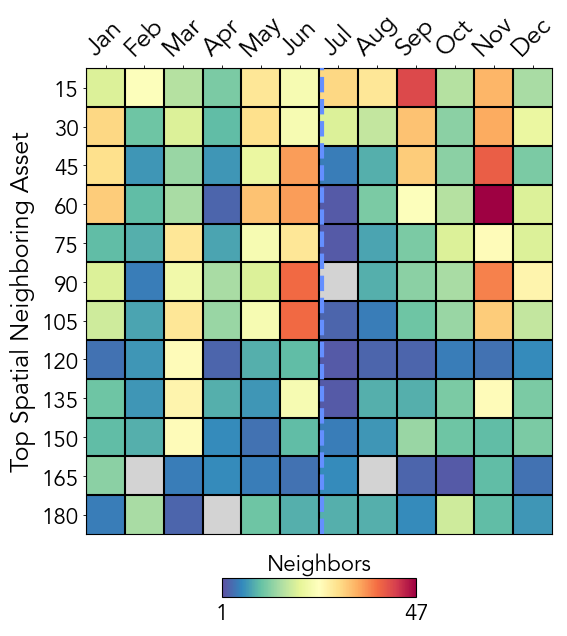

12 193
[0 1 2] [  74 1665  280] 0.2339348253215954
(2019,) (67881,) (2019,) (150,)


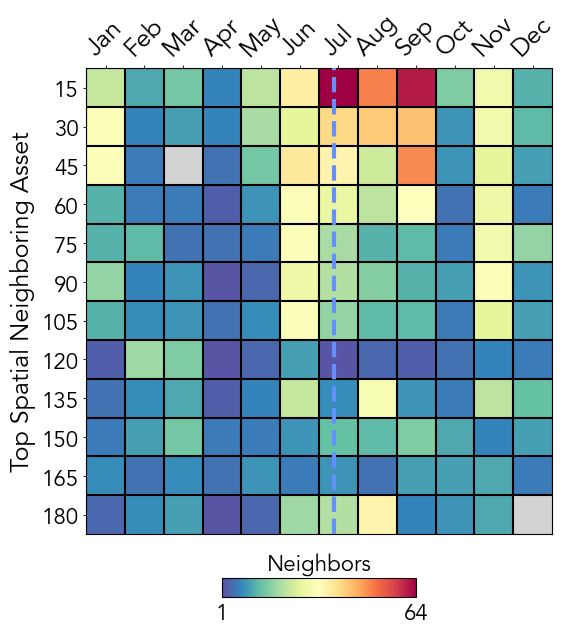

12 213
[0 1 2] [  81 1681  257] 0.20396701098892908
(2019,) (67881,) (2019,) (150,)


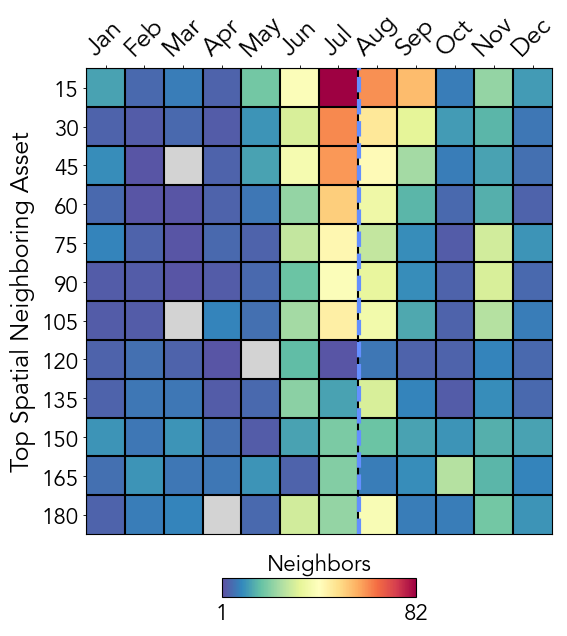

13 12
[0 1 2] [  63 1731  225] 0.24085260565517333
(2019,) (67881,) (2019,) (150,)


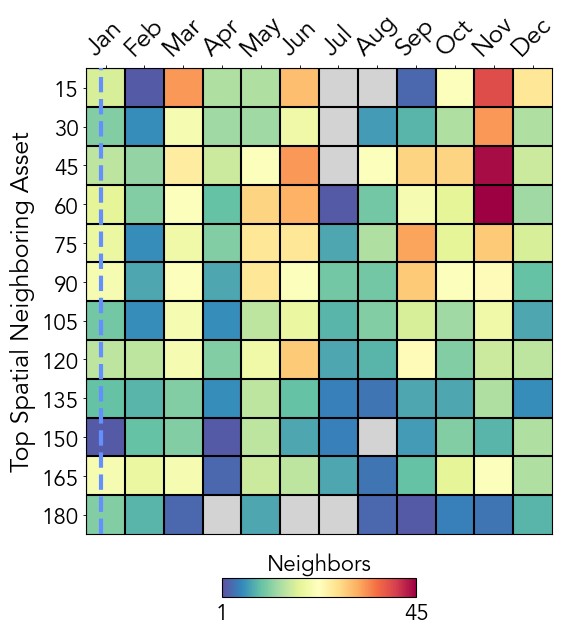

13 23
[0 1 2] [ 535 1071  413] 0.21832972911849718
(2019,) (67881,) (2019,) (150,)


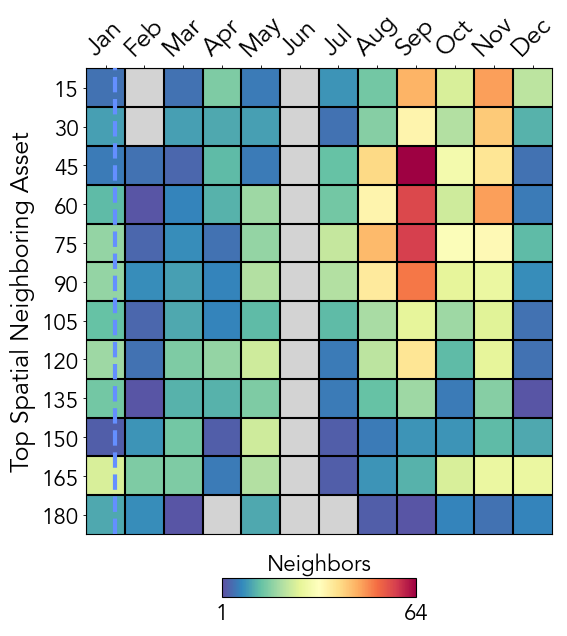

13 169
[0 1 2] [ 618 1245  156] 0.2526058640342483
(2019,) (67881,) (2019,) (150,)


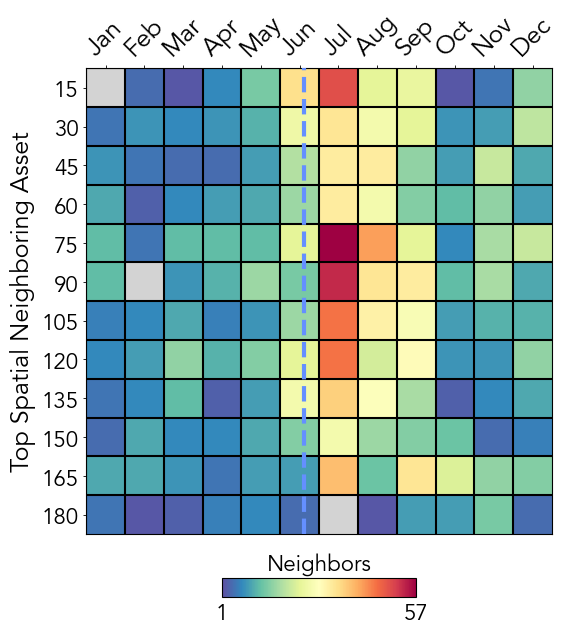

13 190
[0 1 2] [ 576 1274  169] 0.21831326735681403
(2019,) (67881,) (2019,) (150,)


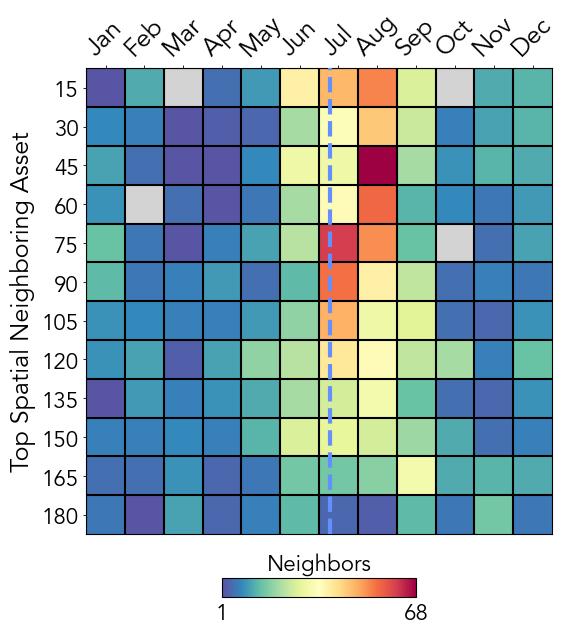

13 205
[0 1 2] [  78 1573  368] 0.20979288821557812
(2019,) (67881,) (2019,) (150,)


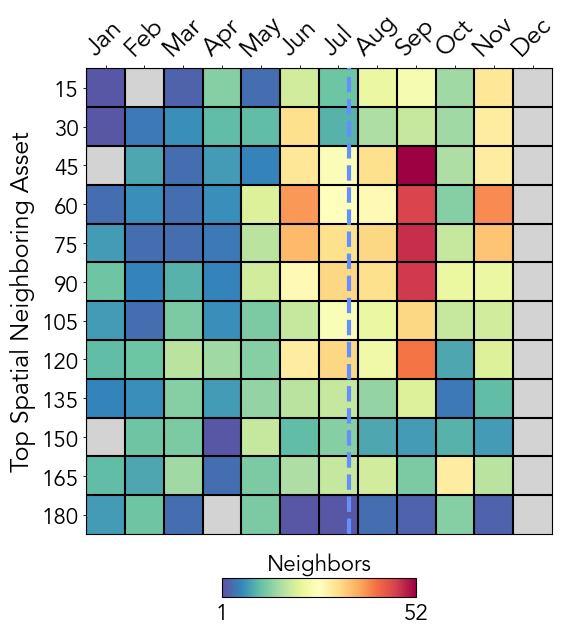

13 208
[0 1 2] [  38 1590  391] 0.23109472401635567
(2019,) (67881,) (2019,) (150,)


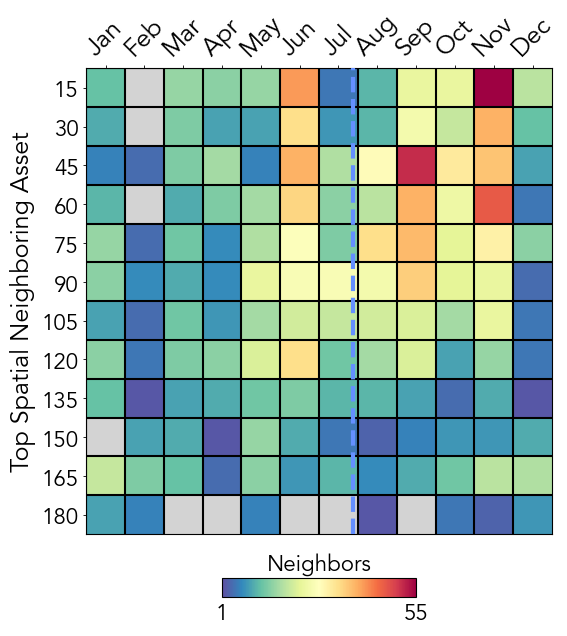

13 350
[0 1 2] [  44 1487  488] 0.20441632828474637
(2019,) (67881,) (2019,) (150,)


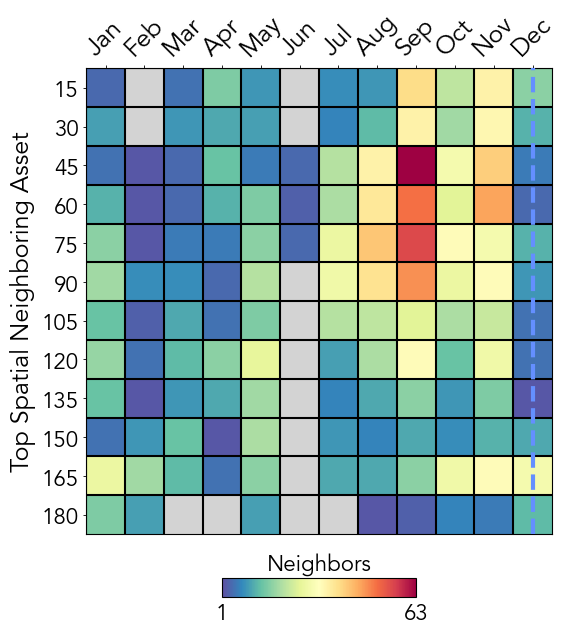

14 37
[0 1 2] [  41 1507  471] 0.20719136633795418
(2019,) (67881,) (2019,) (150,)


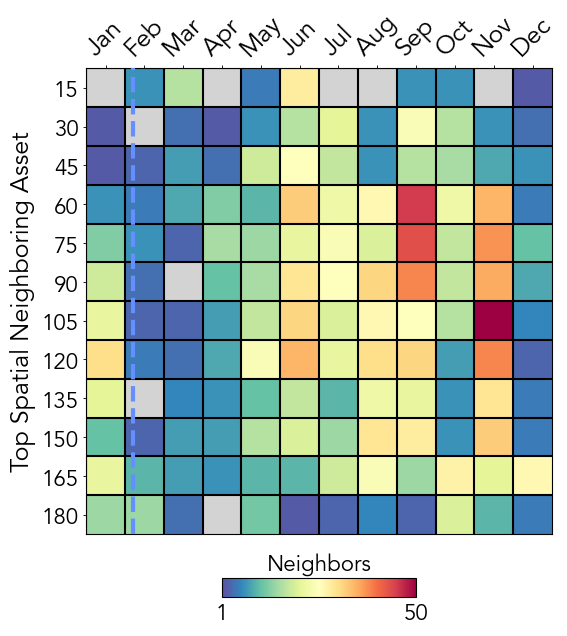

14 343
[0 1 2] [ 398 1413  208] 0.21196733850383748
(2019,) (67881,) (2019,) (150,)


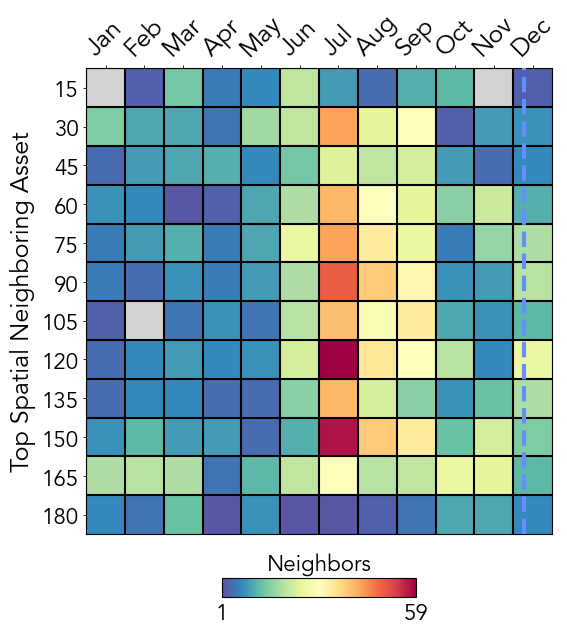

15 169
[0 1 2] [1003  851  165] 0.2047010026944185
(2019,) (67881,) (2019,) (150,)


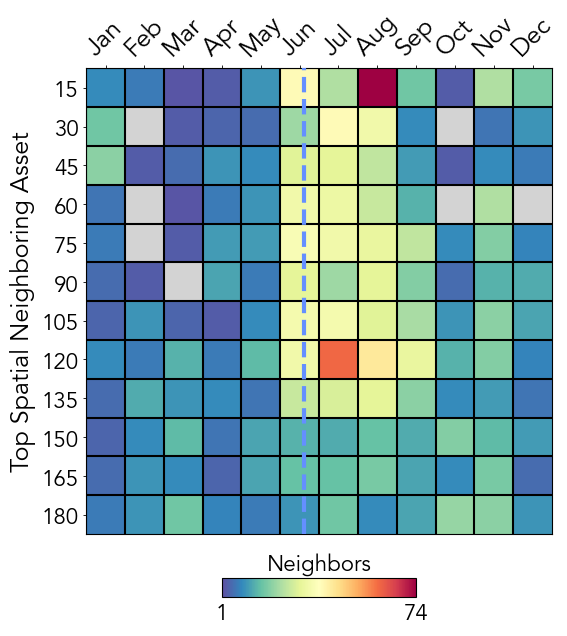

15 319
[0 1 2] [ 427 1349  243] 0.24355811078877407
(2019,) (67881,) (2019,) (150,)


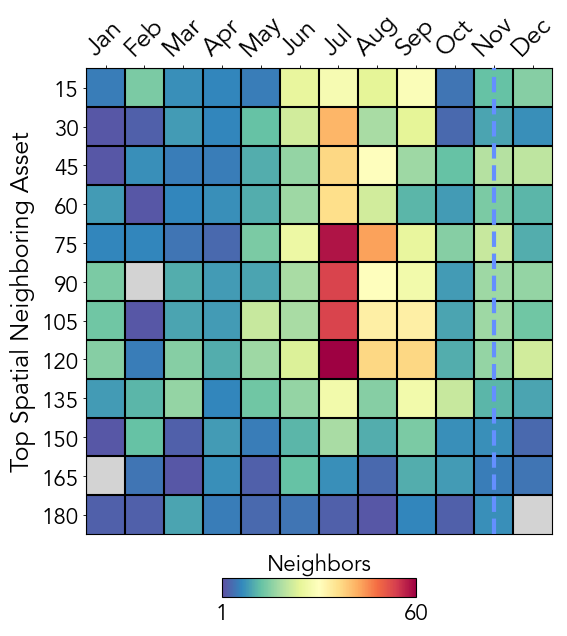

16 12
[0 1 2] [  48 1689  282] 0.2445879328347582
(2019,) (67881,) (2019,) (150,)


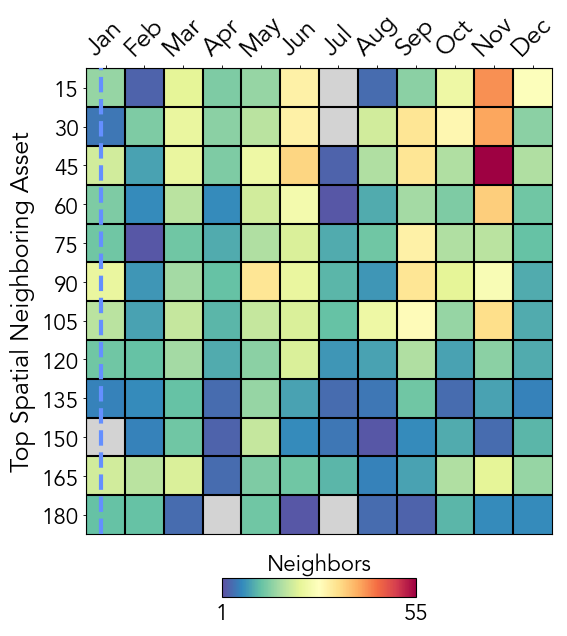

16 23
[0 1 2] [  53 1404  562] 0.24006752007631021
(2019,) (67881,) (2019,) (150,)


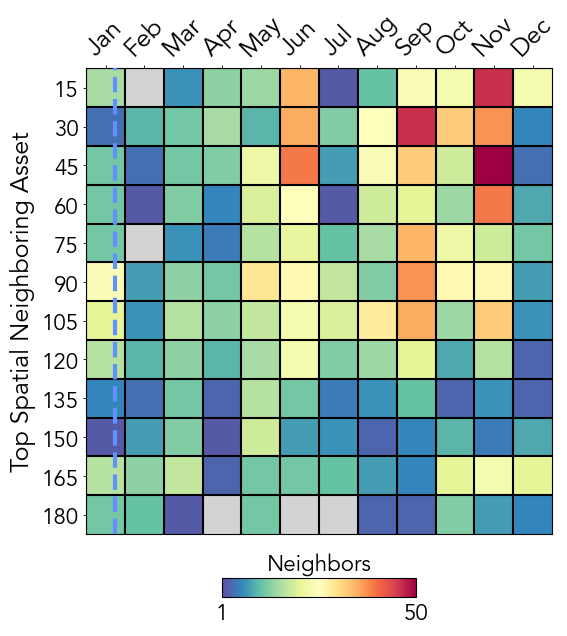

16 124
[0 1 2] [  49 1778  192] 0.2360528659805647
(2019,) (67881,) (2019,) (150,)


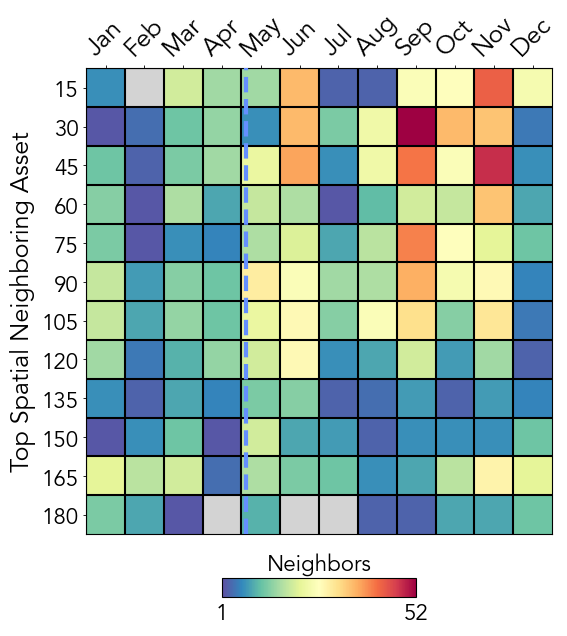

16 205
[0 1 2] [  57 1480  482] 0.23527358208266871
(2019,) (67881,) (2019,) (150,)


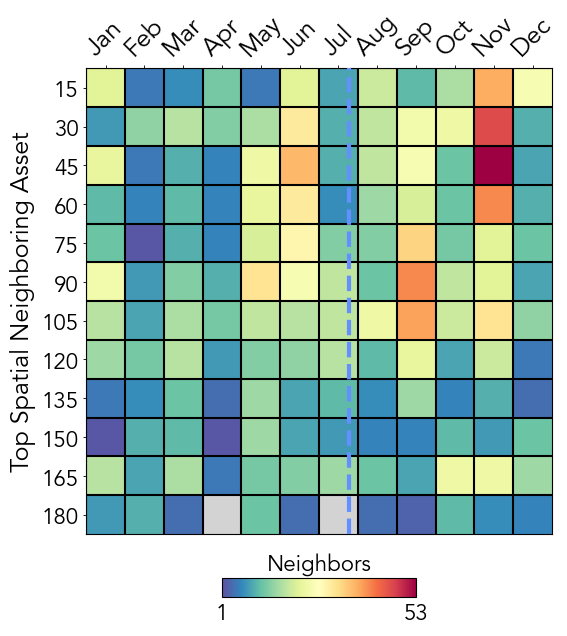

16 208
[0 1 2] [  54 1509  456] 0.23883149284501937
(2019,) (67881,) (2019,) (150,)


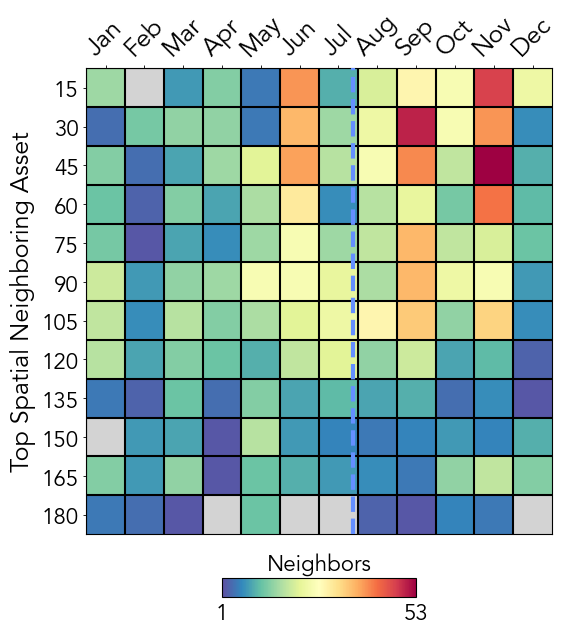

16 212
[0 1 2] [  48 1585  386] 0.21557397630483627
(2019,) (67881,) (2019,) (150,)


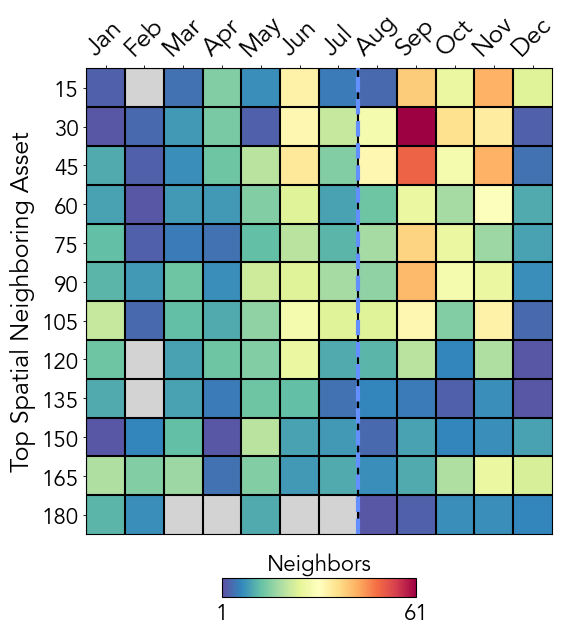

16 295
[0 1 2] [1017  752  250] 0.2062792130653589
(2019,) (67881,) (2019,) (150,)


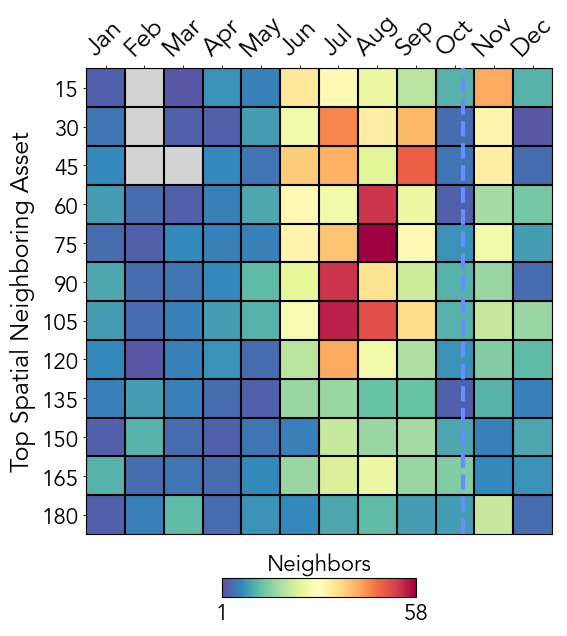

16 329
[0 1 2] [  34 1592  393] 0.23864978899725603
(2019,) (67881,) (2019,) (150,)


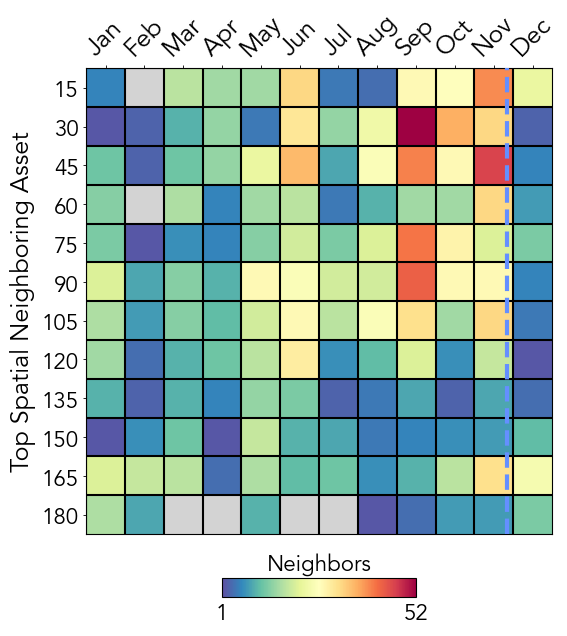

17 5
[0 1 2] [ 312 1452  255] 0.22774999056868098
(2019,) (67881,) (2019,) (150,)


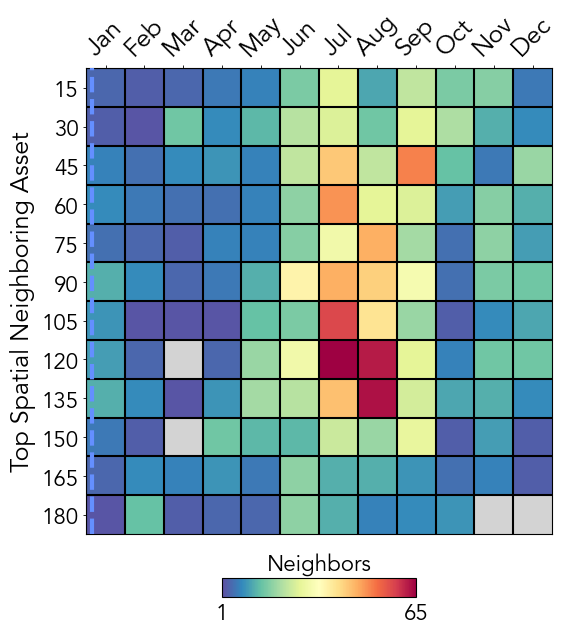

17 352
[0 1 2] [792 833 394] 0.2020882164517093
(2019,) (67881,) (2019,) (150,)


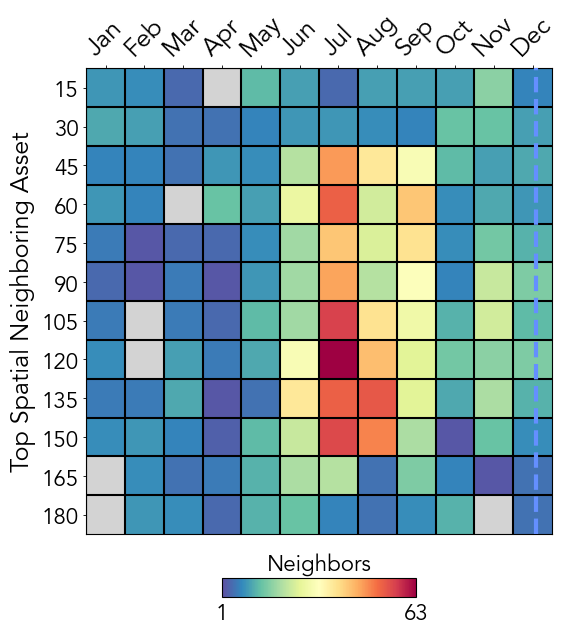

18 43
[0 1 2] [ 547 1321  151] 0.2536555925751242
(2019,) (67881,) (2019,) (150,)


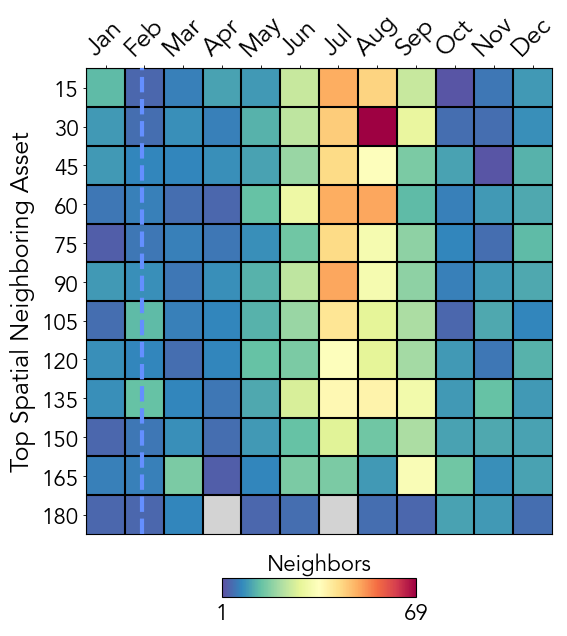

18 124
[0 1 2] [  39 1824  156] 0.2164408784338552
(2019,) (67881,) (2019,) (150,)


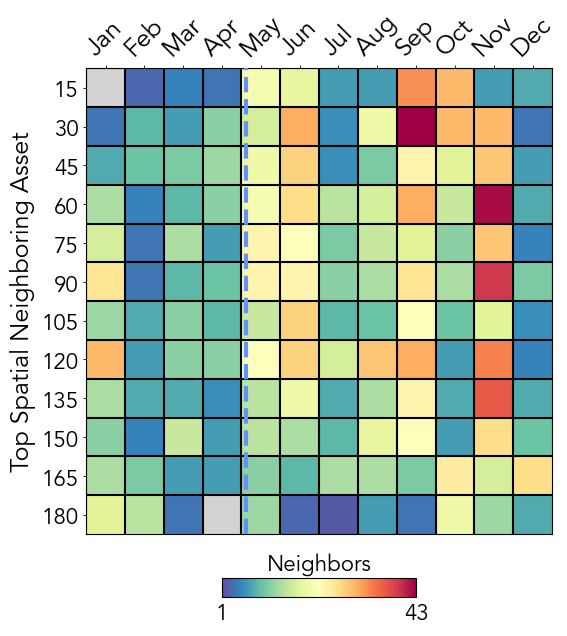

18 319
[0 1 2] [  51 1718  250] 0.26286940913044526
(2019,) (67881,) (2019,) (150,)


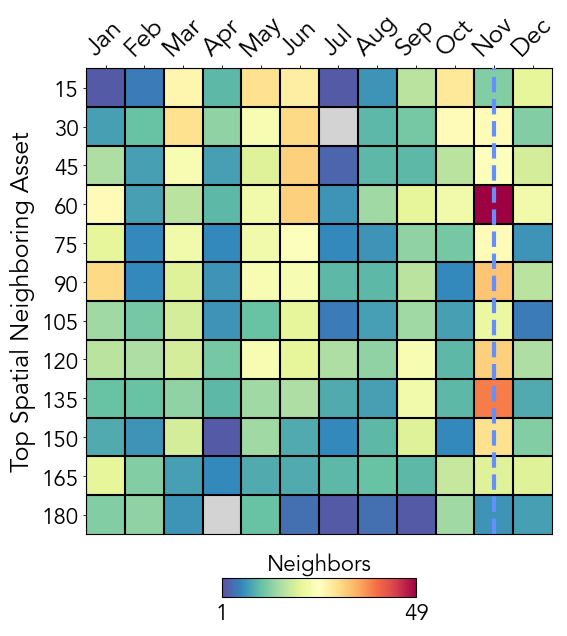

18 329
[0 1 2] [  46 1485  488] 0.23842533656166762
(2019,) (67881,) (2019,) (150,)


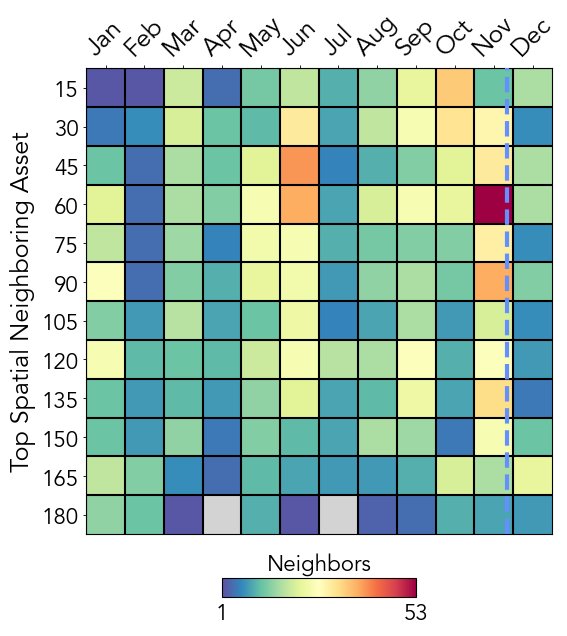

18 340
[0 1 2] [664 943 412] 0.2238926846012128
(2019,) (67881,) (2019,) (150,)


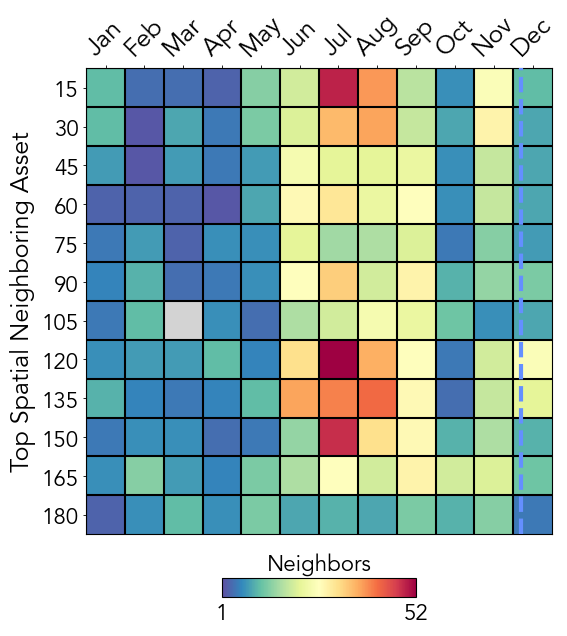

19 43
[0 1 2] [ 180 1619  220] 0.24321076805076358
(2019,) (67881,) (2019,) (150,)


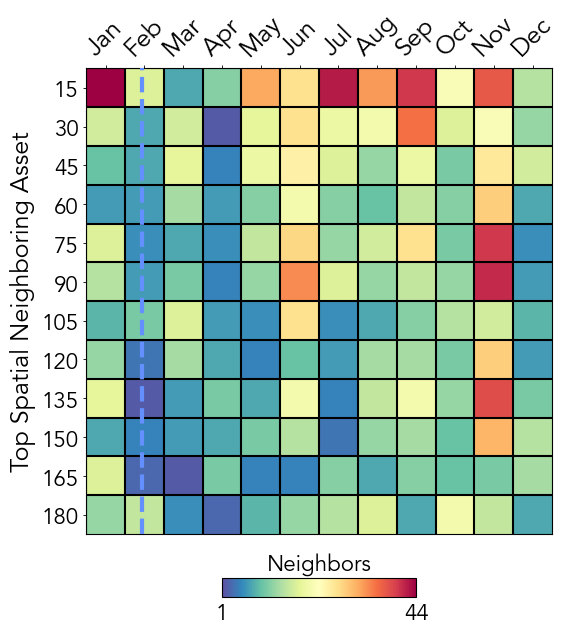

19 182
[0 1 2] [ 552 1278  189] 0.22898358507520436
(2019,) (67881,) (2019,) (150,)


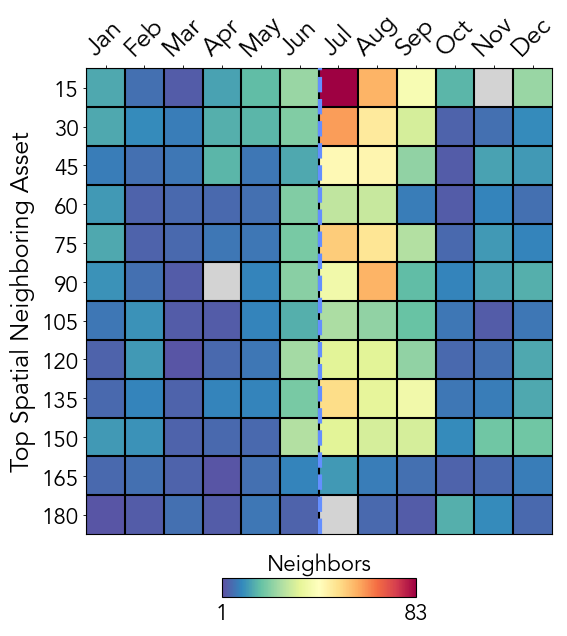

19 191
[0 1 2] [ 116 1595  308] 0.22962365496299972
(2019,) (67881,) (2019,) (150,)


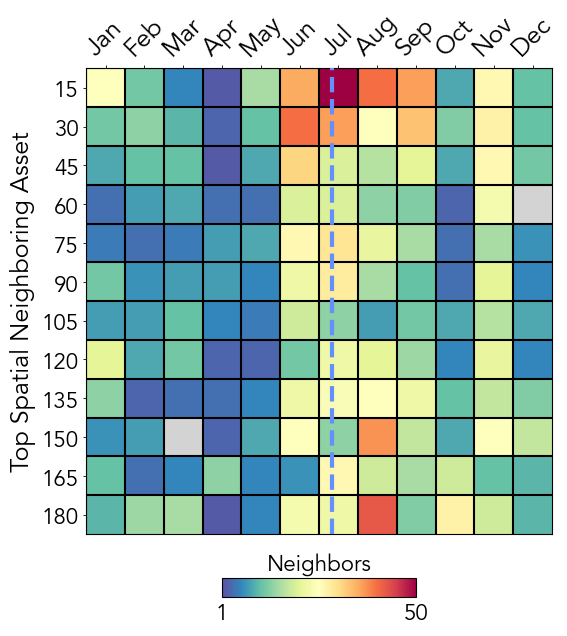

19 193
[0 1 2] [ 174 1593  252] 0.25261351653228437
(2019,) (67881,) (2019,) (150,)


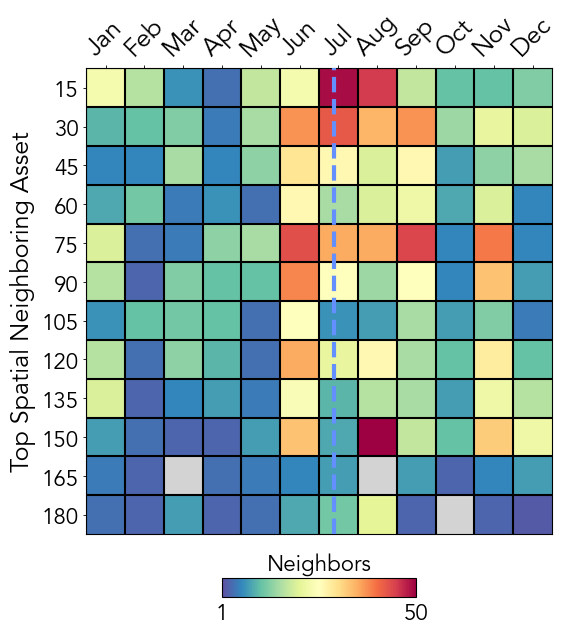

19 202
[0 1 2] [  46 1697  276] 0.20352055139534603
(2019,) (67881,) (2019,) (150,)


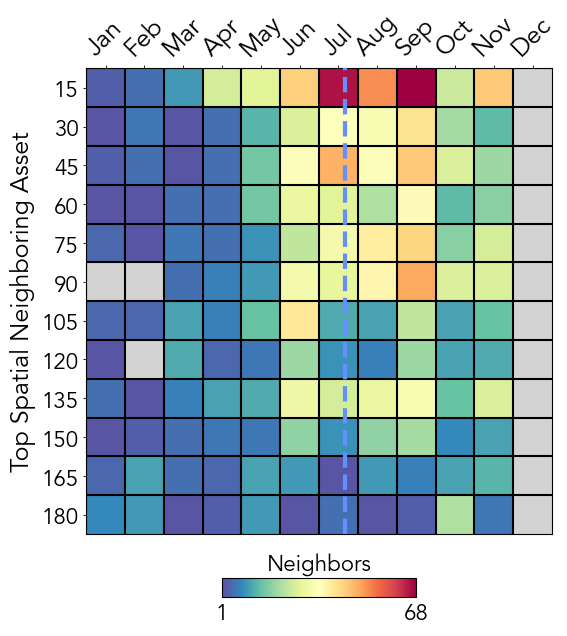

19 212
[0 1 2] [  57 1614  348] 0.21150609780631321
(2019,) (67881,) (2019,) (150,)


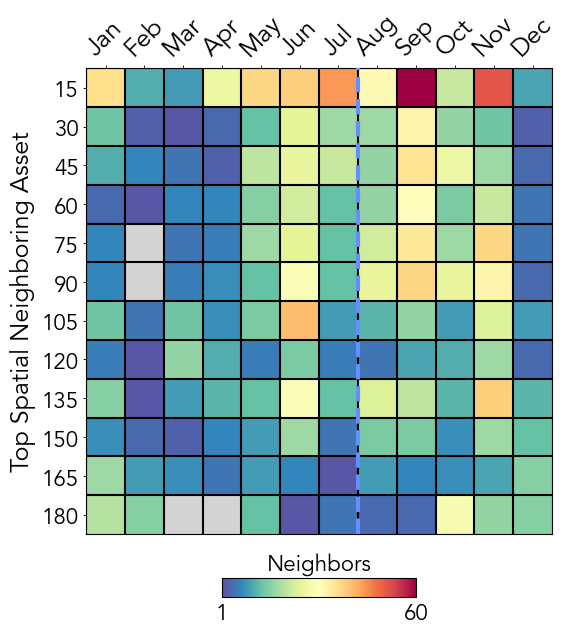

19 226
[0 1 2] [ 213 1649  157] 0.24161749987541759
(2019,) (67881,) (2019,) (150,)


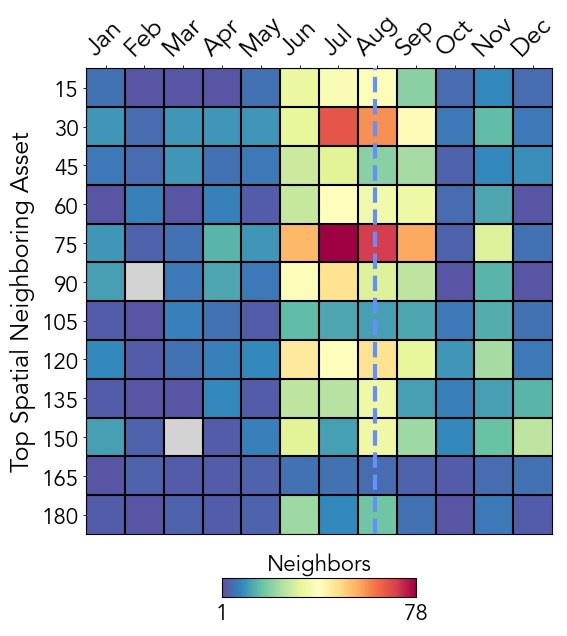

19 232
[0 1 2] [  61 1797  161] 0.2129272652009911
(2019,) (67881,) (2019,) (150,)


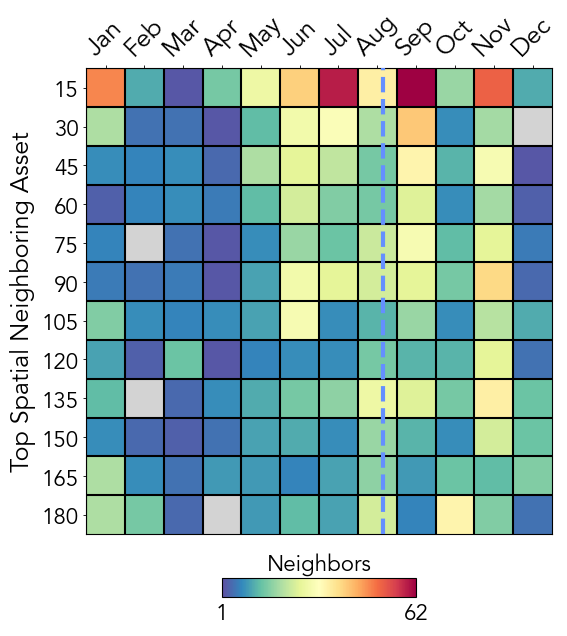

19 283
[0 1 2] [ 549 1257  213] 0.20605089794787218
(2019,) (67881,) (2019,) (150,)


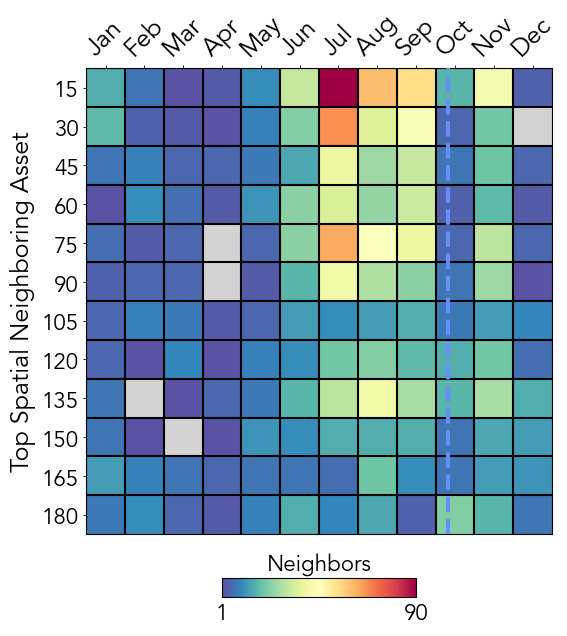

19 319
[0 1 2] [  45 1683  291] 0.232175478073055
(2019,) (67881,) (2019,) (150,)


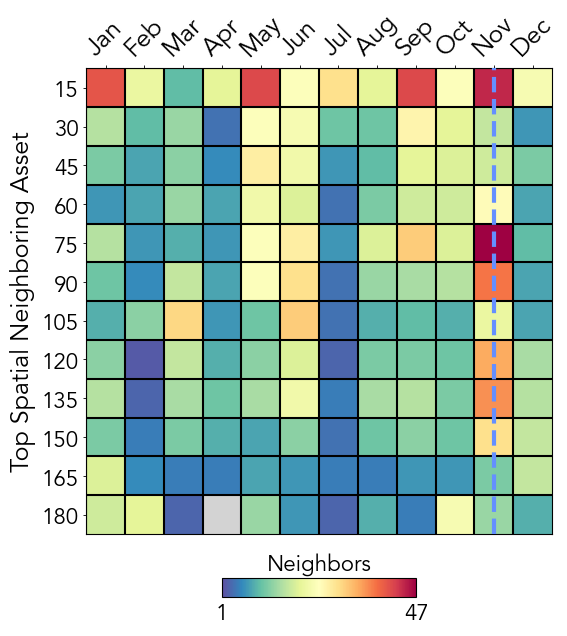

19 340
[0 1 2] [361 946 712] 0.2034423226322061
(2019,) (67881,) (2019,) (150,)


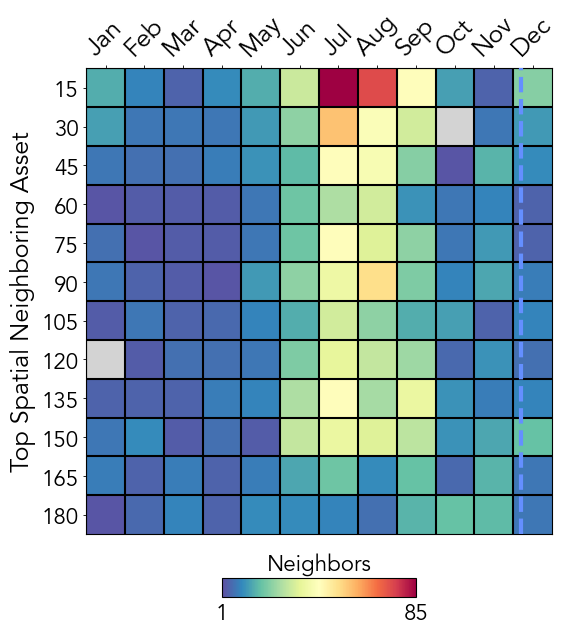

19 348
[0 1 2] [  58 1665  296] 0.23709118486447484
(2019,) (67881,) (2019,) (150,)


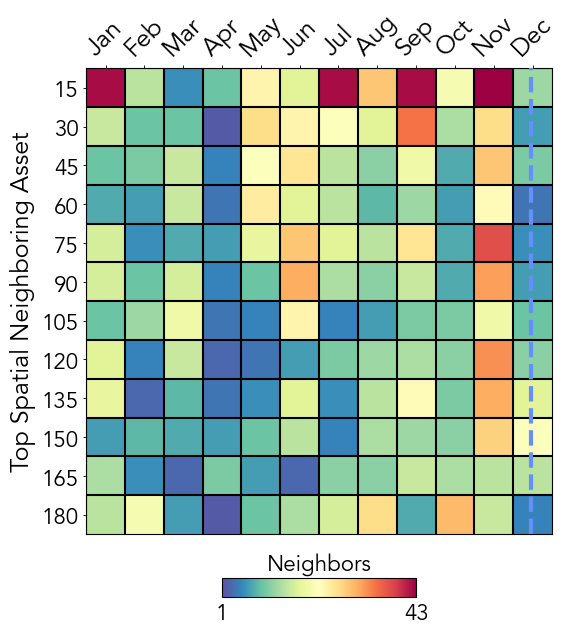

19 351
[0 1 2] [ 562 1133  324] 0.2006886519956104
(2019,) (67881,) (2019,) (150,)


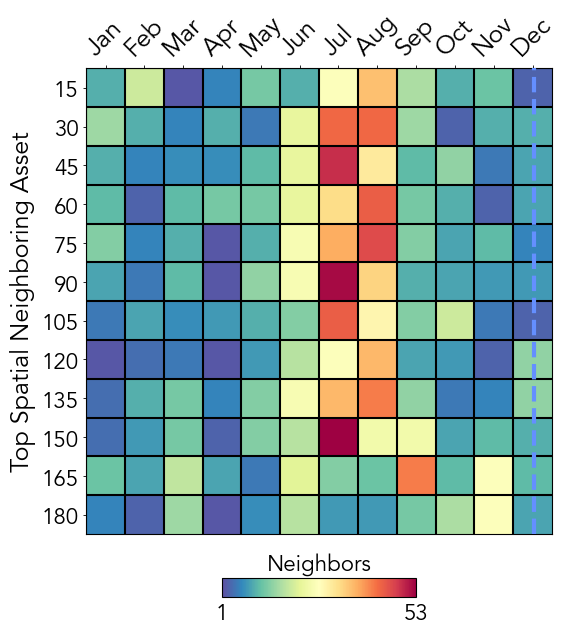

KeyboardInterrupt: 

In [605]:
# interval = 144

# for asset in range(10, 20):
    
#     for day in range(360):
        
#         _fdu = functional_dynamic_update(
#             _distances = {"temporal": "seasonal_equinox", 
#                           "spatial": "haversine", 
#                           "fusion": "dynamic"},
#             name = assets_ts_[asset],
#             date = T_ts_[day, interval],
#         )
        
#         # Filter solar hours with loading solar set
#         interval_mask = mask_intervals(
#             F_tr_, 
#             E_tr_biased_, 
#             t_tr_, 
#             day, 
#             day_window = 7,
#         )
        
#         _fdu.fit(
#             F_tr_,
#             E_tr_lin_,
#             dt_,
#             X_ = X_tr_,
#             t_ = t_tr_,
#             interval_mask = interval_mask,
#             n_samples_per_hour = 12,
#         )
#         M_ = _fdu.predict(
#             F_ts_[day, :interval, asset], 
#             E_ts_lin_[day, :, asset], 
#             X_ts_[asset, :], 
#             t_ts_[day],
#             forget_rate_f = get_hyper(hyper_, "forget_rate_f", interval),
#             forget_rate_e = get_hyper(hyper_, "forget_rate_e", interval),
#             lookahead_rate = get_hyper(hyper_, "lookahead_rate", interval),
#             length_scale_f = get_hyper(hyper_, "length_scale_f", interval),
#             length_scale_e = get_hyper(hyper_, "length_scale_e", interval),
#             length_scale_d = get_hyper(hyper_, "length_scale_d", interval),
#             sigma = get_hyper(hyper_, "sigma", interval),
#             nu = get_hyper(hyper_, "nu", interval),
#             kappa_0 = get_hyper(hyper_, "kappa_0", interval),
#             kappa = get_hyper(hyper_, "kappa", interval),
#             p_fusion = get_hyper(hyper_, "p_fusion", interval),
#         )
#         # print(_fdu.idx_fed_)
#         # print(_fdu.idx_x_.shape)
#         #print(np.exp(_fdu.xi), _fdu.r, _fdu.d_max)
#         x_, y_ = np.unique(_fdu.arg_fed_[_fdu.idx_fed_], return_counts=True)
#         if (x_.shape[0] == 3) & (M_.mean() > 0.2):
#             if (y_[2] > 150):
    
#                 print(asset, day)
#                 print(x_, y_, M_.mean())
    
#                 _fig, _ax = plt.subplots(figsize=(7.5, 6.25), constrained_layout=True)
                
#                 plotter.selected_scenarios_heatmap(
#                     _fig, 
#                     _ax, 
#                     palette_,
#                     _fdu._haversine_dist, 
#                     _fdu.idx_fed_, 
#                     _fdu.idx_x_local_,
#                     _fdu.d_x_,
#                     _fdu.x_, 
#                     T_tr_[:, interval], 
#                     X_ts_,
#                     _fdu.date,
#                     colorbar = True,
#                 )
                            
#                 plt.show()
                
# # Plotting variables
# e_biased_ = E_ts_biased_[day, :, asset]
# f_hat_ = F_ts_[day, interval:, asset]
# e_lin_ = E_ts_lin_[day, :, asset]
# x_ts_ = X_ts_[asset, :]
# e_ = E_ts_[day, :, asset]
# f_ = F_ts_[day, :interval, asset]

# file_name = f"{resource}-{asset}-{day}-{interval}-asset"
# print(file_name)
# # 10 167
# # 10 337
# # 11 23
# # 11 340
# # 12 43
# # 12 213
# # 13 23
# # 13 205
# # 13 350
# # 14 343
# # 15 169
# # 15 319
# # 16 12
# # 16 23
# # 16 124
# # 16 212
# # 16 295
# # 17 5
# # 17 352
# # 18 43
# # 19 182
# # 19 202
# # 19 226
# # 19 340
# plt.figure()
# plt.plot(F_ts_[day, :, asset])
# plt.plot(e_)
# plt.plot(e_lin_)
# plt.plot(e_biased_)
# plt.ylim(0, 1)
# plt.show()

# plt.figure()
# plt.plot(M_.T)
# plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


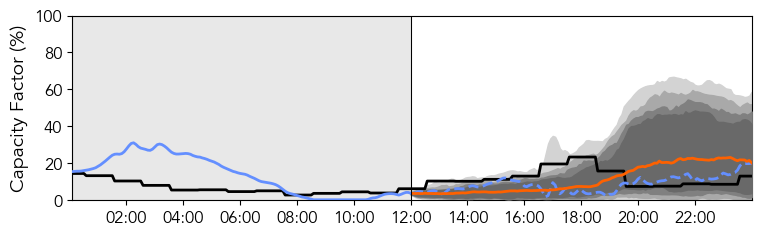

In [45]:
# Calculate confidence intervals from Directional Quantiles
alpha_ = [0.1, 0.2, 0.3, 0.4]
M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    n_basis=20
)

f_median_ext_, _upper, _lower = _fdu.ecdf_confidence_bands(
    M_int_, 
    alpha_
)


f_wmedian_ext_, _wupper, _wlower = _fdu.weighted_ecdf_confidence_bands(
    M_int_, 
    _fdu.w_prime_,
    alpha_
)

_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_envelope(
    _fig, 
    _ax, 
    palette_,
    _wupper, 
    _wlower, 
    f_wmedian_ext_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_,
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    color = palette_.loc[3, "ibm"],
    CR = "CI",
    label = r"$\hat{\mu}_{med} (s)$",
    range_ = [0, 287],
    legend_1 = False,
    legend_2 = False,
)

_ax.legend(
    frameon = False,
    #loc = (0.025, .8),
    fontsize = 11,
    columnspacing = 0.5,
    handletextpad = 0.25,
    ncol = 1
)

plt.savefig(IMAGES / f"median_edf-{file_name}.pdf")

plt.show()

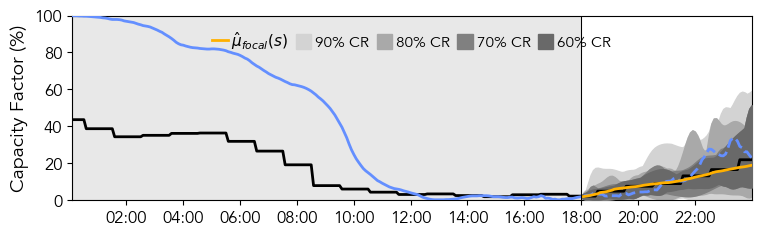

In [480]:
# Samples in each confidence band
score = 'FCS'
distance = "fknn"
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()

M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    n_basis=20
)

J_ = _fdu.focal_curve_envelope(
    _depth, 
    M_int_, 
    distance
)

k_ = get_band_fraction(
    envelope_, 
    alpha_, 
    interval, 
    distance, 
    score
)

f_focal_ext_, _upper, _lower = _fdu.focal_envelope_confidence_bands(
    alpha_, 
    k_
)

_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_focal_ext_, f_, f_hat_, e_biased_, dx_,
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    color = palette_.loc[4, "ibm"],
    label = r"$\hat{\mu}_{focal} (s)$",
    CR = "CR",
    range_ = [0, 287],
    legend_1 = False,
    legend_2 = True,
)

_ax.legend(
    frameon = False,
    #loc = (0.025, .8),
    loc ='upper center',
    fontsize = 11,
    columnspacing = 0.5,
    handletextpad = 0.25,
    ncol = 5,
)

plt.savefig(IMAGES / f"focal_curve_envelope-{file_name}.pdf")

plt.show()

# Visualization Utils

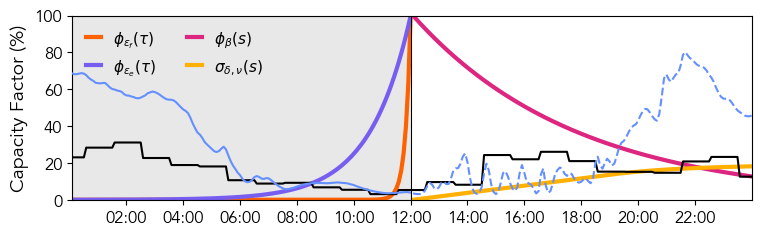

In [77]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_forecast_parameters(
    _fig, 
    _ax, 
    palette_,
    _fdu.phi_, 
    _fdu.psi_, 
    _fdu.eta_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    range_ = [0, 287],
    labels_1 = False,
    labels_2 = True,
)

_ax.legend(
    frameon = False,
    ncol = 2,
    #loc = (0.0125, 0.3),
    fontsize = 11
)

plt.savefig(IMAGES / f"hyper-{file_name}.pdf")

plt.show()

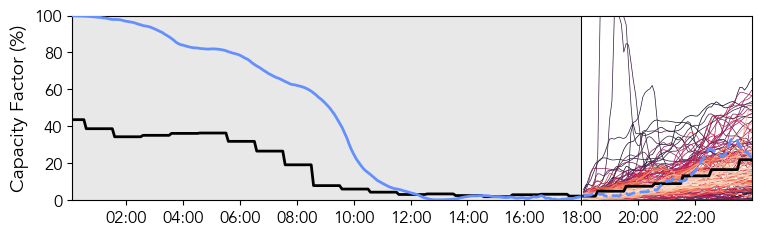

In [471]:
distance = 'MBD'
_depth = ModifiedBandDepth()

M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    n_basis=20
)

depth_score_, depth_rank_ = _fdu.get_depth(_depth, M_int_)

_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_depth(
    _fig, _ax, palette_,
    M_, f_, f_hat_, e_biased_, depth_score_, dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    range_ = [0, 287],
    colorbar = False,
)

# _ax.legend(
#     frameon = False,
#     #loc = (0.175, .725),
#     fontsize = 11,
#     columnspacing = 0.5,
#     handletextpad = 0.2,
#     ncol = 1
# )

plt.savefig(IMAGES / f"ranking-{distance}_{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


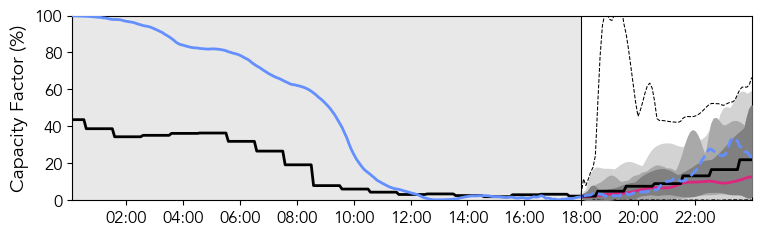

In [472]:
# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
    M_int_, 
    depth_score_
)

_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_,
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    range_ = [0, 287],
    legend_1 = False,
    legend_2 = False,
)

_ax.legend(frameon = False,
           #loc = (0.025, .8),
           fontsize = 11,
           columnspacing = 0.5,
           handletextpad = 0.2,
           ncol = 1)

plt.savefig(IMAGES / f"fboxplot-{distance}_{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


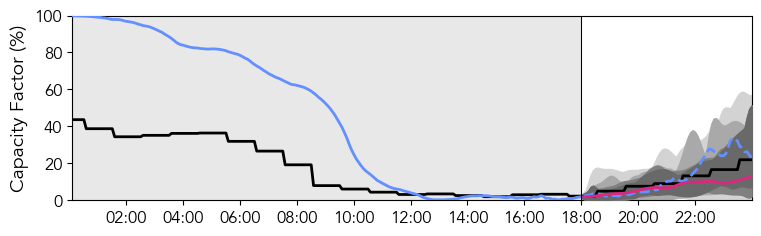

In [473]:
# Samples in each confidence band
score = 'FCS'
distance = 'MBD'
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()


M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    n_basis=20
)

k_ = get_band_fraction(
    envelope_, 
    alpha_, 
    interval, 
    distance, 
    score
)

f_deepest_ext_, _upper, _lower = _fdu.depth_confidence_bands(
    _depth, 
    M_int_, 
    alpha_, 
    k_
)

_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    color = palette_.loc[2, "ibm"],
    label = r"$\hat{\mu}_{deep} (s)$",
    CR = "CR",
    range_ =[0, 287],
    legend_1 = False,
    legend_2 = False,
)

_ax.legend(
    frameon = False,
    #loc = (0.1875, 0.825),
    fontsize = 11,
    columnspacing = 0.5,
    handletextpad = 0.25,
    ncol = 1,
)

plt.savefig(IMAGES / f"{distance}_bands-{file_name}.pdf")

plt.show()

(144,)


ValueError: x and y must have same first dimension, but have shapes (144,) and (72, 1)

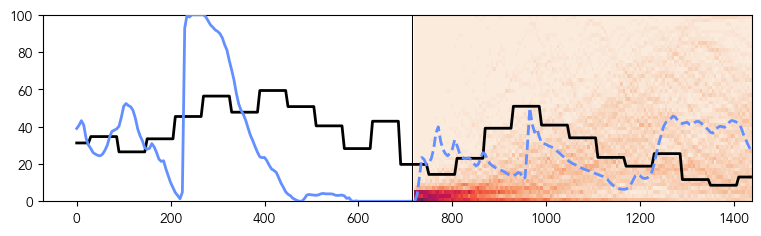

In [733]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_density_heatmap(
    _fig, 
    _ax, 
    palette_,
    M_, 
    f_wmedian_ext_, 
    f_deepest_ext_, 
    f_focal_ext_,
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_, 
    interval,
    range_ = [0, 287],
    colorbar = False,
    legend_1 = True,
    legend_2 = False,
)

_ax.legend(
    frameon = False,
    loc = 'upper center',
    fontsize = 11,
    columnspacing = 0.5,
    handletextpad = 0.25,
    ncol = 3
)
#0 0.12 0.5
#143 0.043333333333333335 0.5

plt.savefig(IMAGES / f"heatmap-{file_name}.pdf")

plt.show()

[-99.3769  34.3047]


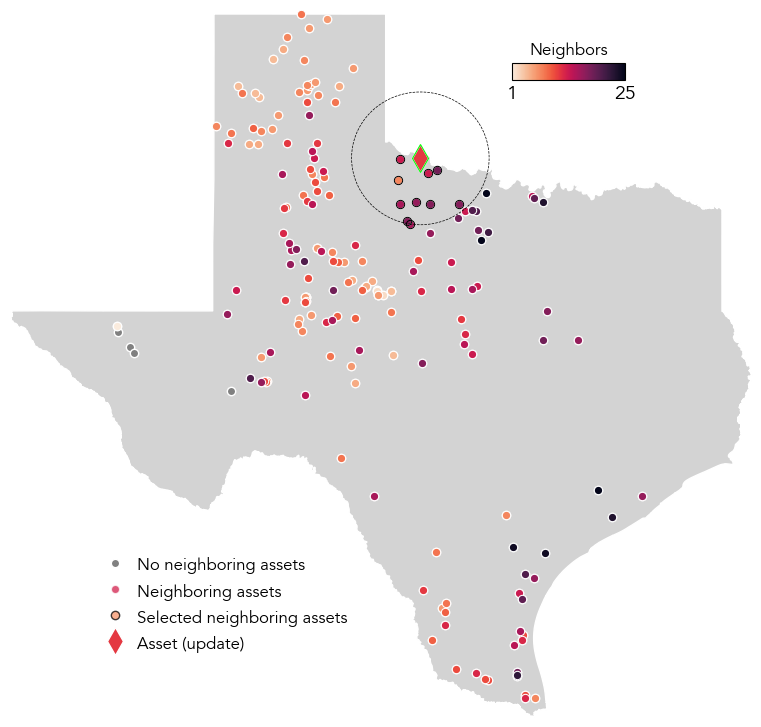

In [43]:
_fig, _ax = plt.subplots(figsize=(7.5, 7.5), constrained_layout=True)
print(_fdu.x_)

plotter.plot_frequency_map(
    _fig, _ax, palette_, _TX, _fdu, X_tr_, X_ts_, 
    _fdu.x_, 
    _fdu.idx_fed_,
    _fdu.idx_x_, 
    _fdu.r,
)

_ax.legend(
    frameon = False, 
    bbox_to_anchor = (0.475, 0.25), 
    ncol = 1, 
    fontsize = 12
)

plt.savefig(IMAGES / f"spatial_neiboring_assets-{file_name}.pdf")

plt.show()

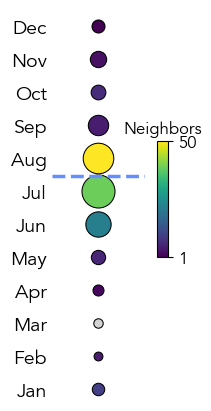

In [24]:
_fig, _ax = plt.subplots(figsize=(2, 4), constrained_layout=True)

plotter.scenarios_frequency_dates(
    _fig, 
    _ax, 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_,
    T_tr_[:, interval], 
    _fdu.date,
    scale = 1.125,
    colorbar = True,
)

plt.savefig(IMAGES / f"temporal_neiboring_assets-{file_name}.pdf")

plt.show()

(2019,) (67881,) (2019,) (150,)


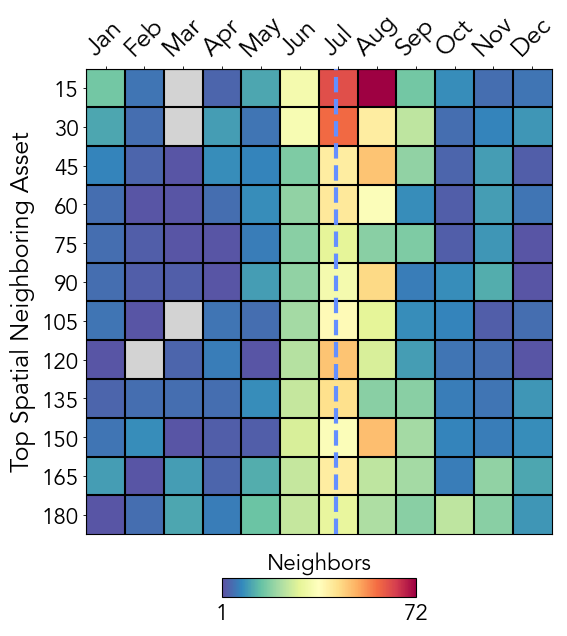

In [25]:
_fig, _ax = plt.subplots(figsize=(7.5, 6.25), constrained_layout=True)

plotter.selected_scenarios_heatmap(
    _fig, 
    _ax, 
    palette_,
    _fdu._haversine_dist, 
    _fdu.idx_fed_, 
    _fdu.idx_x_local_,
    _fdu.d_x_,
    _fdu.x_, 
    T_tr_[:, interval], 
    X_ts_,
    _fdu.date,
    colorbar = True,
)

plt.savefig(IMAGES / f"seasonly_neiboring_assets-{file_name}.pdf")

plt.show()

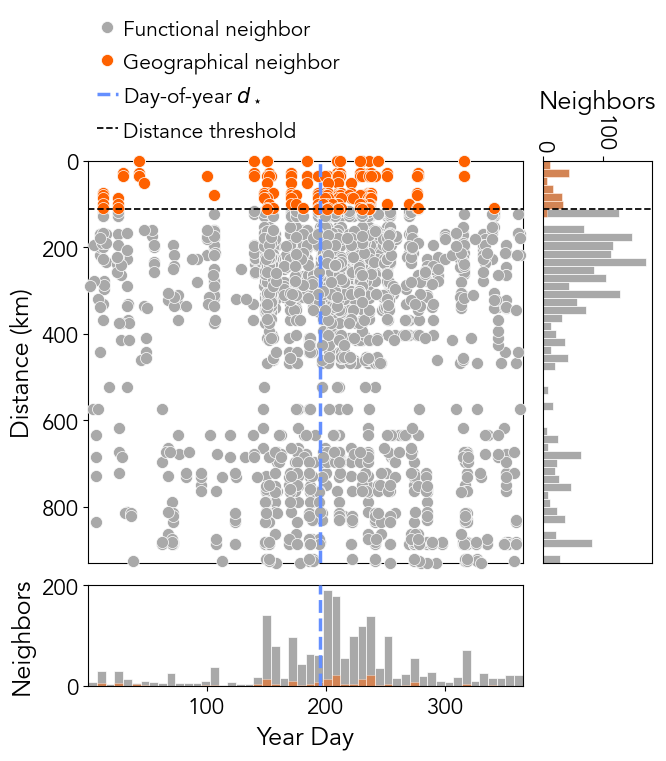

In [760]:
_fig, _ax = plt.subplot_mosaic(
    [["A", "B"], ["C", "."]],
    figsize=(6.5, 7.5),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(1, 0.25), height_ratios=(1, 0.25)),
)

plotter.plot_filtered_scenarios(
    _fig, 
    _ax["A"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_, 
    _fdu.idx_x_local_, 
    _fdu.d_x_,
    t_tr_, 
    t_ts_[day], 
    _fdu.r,
)

plotter.plot_distance_histogram(
    _fig, 
    _ax["B"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.d_x_, 
    _fdu.r,
)

plotter.plot_dates_histogram(
    _fig, 
    _ax["C"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.d_x_,
    t_tr_, 
    t_ts_[day], 
)

_ax["A"].legend(
    frameon = False,
    ncol = 1,
    columnspacing = 0.625,
    handletextpad = 0.25,
    loc = (0.0, 1.025),
    fontsize = 15,
)

plt.savefig(IMAGES / f"kNN_frequency-{file_name}.pdf")

plt.show()

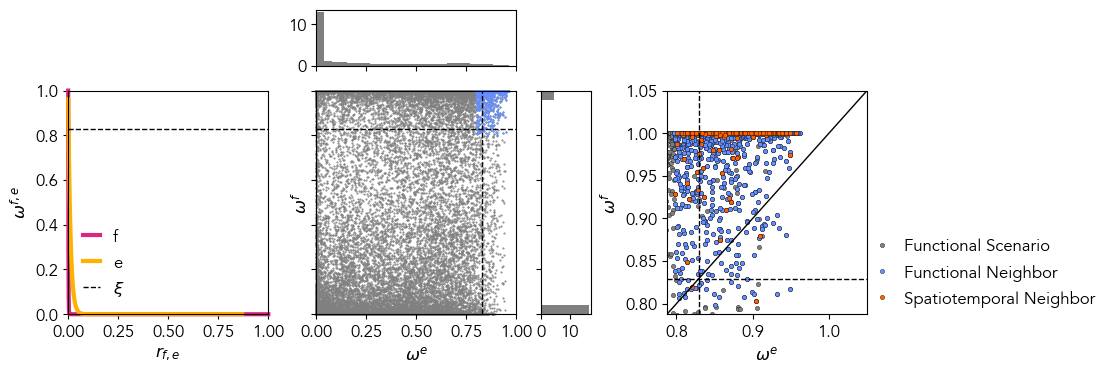

In [659]:
fig, _ax = plt.subplot_mosaic(
    [[".", ".", "e", ".", ".", "."],
     ["A", "A", "B", "f", "C", "C"],
     ["A", "A", "B", "f", "C", "C"],],
    figsize=(11, 3.625),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(2, 2, 4, 1, 2, 2), height_ratios=(1, 2, 2)),
)

plotter.plot_density_threshold(
    _fig, 
    _ax["A"], 
    palette_, 
    _fdu.d_f_, 
    _fdu.d_e_, 
    _fdu.w_f_, 
    _fdu.w_e_, 
    np.exp(_fdu.xi),
    label1 = 'f',
    label2 = 'e',
    ylabel = r"$\omega^{f,e}$",
    xlabel = r"$r_{f,e}$",
)
plotter.plot_functional_neighborhood(
    _fig, 
    _ax["B"], 
    _ax["e"], 
    _ax["f"], 
    palette_, 
    _fdu.idx_fed_, 
    _fdu.w_e_, 
    _fdu.w_f_, 
    np.exp(_fdu.xi),
    xlabel = r"$\omega^{e}$",
    ylabel = r"$\omega^{f}$",
)

plotter.plot_selected_functional_neighbors(
    _fig, 
    _ax["C"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.w_e_, 
    _fdu.w_f_, 
    np.exp(_fdu.xi),
    xlabel = r"$\omega^{e}$",
    ylabel = r"$\omega^{f}$",
)

_ax["C"].legend(
    frameon = False, 
    fontsize = 12, 
    ncol = 1, 
    loc = (1.0, 0.0)
)

plt.savefig(IMAGES / f"fneighbor_fe-{file_name}.pdf")

plt.show()

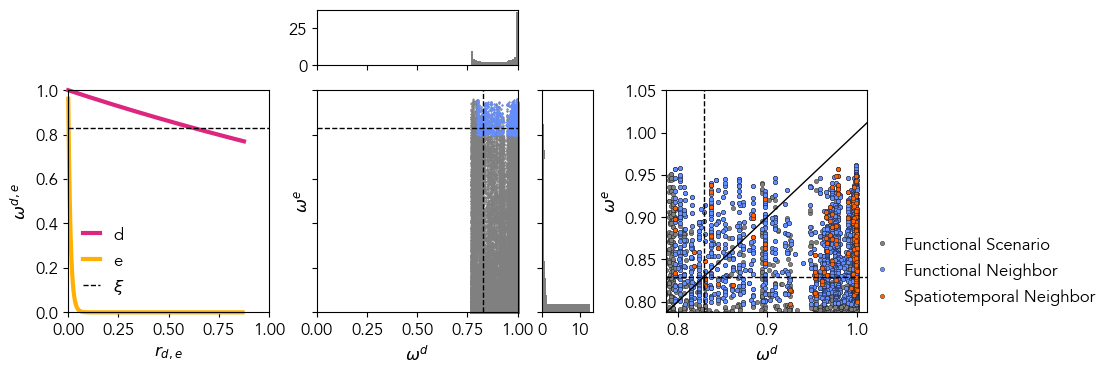

In [660]:
fig, _ax = plt.subplot_mosaic(
    [[".", ".", "e", ".", ".", "."],
     ["A", "A", "B", "f", "C", "C"],
     ["A", "A", "B", "f", "C", "C"],],
    figsize=(11, 3.625),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(2, 2, 4, 1, 2, 2), height_ratios=(1, 2, 2)),
)

plotter.plot_density_threshold(
    _fig, 
    _ax["A"], 
    palette_, 
    _fdu.d_d_, 
    _fdu.d_e_, 
    _fdu.w_d_, 
    _fdu.w_e_, 
    np.exp(_fdu.xi),
    label1 = 'd',
    label2 = 'e',
    ylabel = r"$\omega^{d,e}$",
    xlabel = r"$r_{d,e}$",
)

plotter.plot_functional_neighborhood(
    _fig, 
    _ax["B"], 
    _ax["e"], 
    _ax["f"], 
    palette_, 
    _fdu.idx_fed_, 
    _fdu.w_d_, 
    _fdu.w_e_, 
    np.exp(_fdu.xi),
    xlabel = r"$\omega^{d}$",
    ylabel = r"$\omega^{e}$",
)

plotter.plot_selected_functional_neighbors(
    _fig, 
    _ax["C"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.w_d_, 
    _fdu.w_e_, 
    np.exp(_fdu.xi),
    xlabel = r"$\omega^{d}$",
    ylabel = r"$\omega^{e}$",
)

_ax["C"].legend(
    frameon = False, 
    fontsize = 12, 
    ncol = 1, 
    loc = (1.0, 0.0)
)

plt.savefig(IMAGES / f"fneighbor_ed-{file_name}.pdf")

plt.show()

62118.189259256025


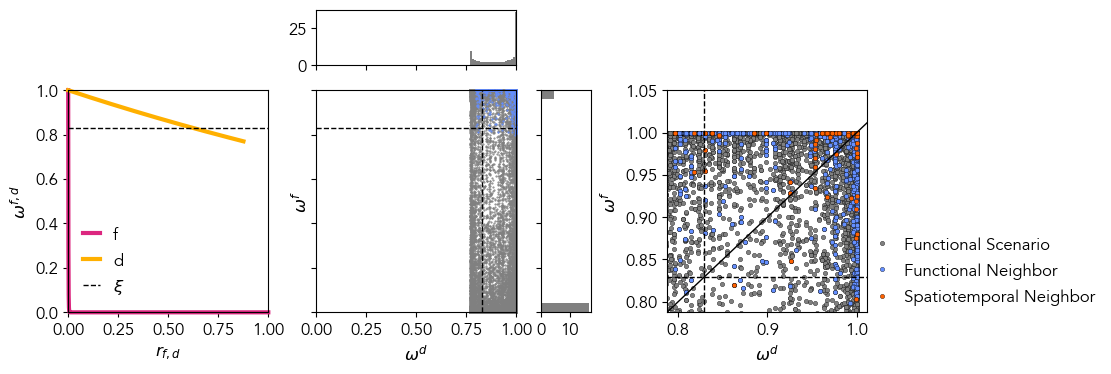

In [661]:
fig, _ax = plt.subplot_mosaic(
    [[".", ".", "e", ".", ".", "."],
     ["A", "A", "B", "f", "C", "C"],
     ["A", "A", "B", "f", "C", "C"],],
    figsize=(11, 3.625),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(2, 2, 4, 1, 2, 2), height_ratios=(1, 2, 2)),
)

plotter.plot_density_threshold(
    _fig, 
    _ax["A"], 
    palette_, 
    _fdu.d_f_, 
    _fdu.d_d_, 
    _fdu.w_f_, 
    _fdu.w_d_, 
    np.exp(_fdu.xi),
    label1 = 'f',
    label2 = 'd',
    ylabel = r"$\omega^{f,d}$",
    xlabel = r"$r_{f,d}$",
)
plotter.plot_functional_neighborhood(
    _fig, 
    _ax["B"], 
    _ax["e"], 
    _ax["f"], 
    palette_, 
    _fdu.idx_fed_, 
    _fdu.w_d_, 
    _fdu.w_f_, 
    np.exp(_fdu.xi),
    xlabel = r"$\omega^{d}$",
    ylabel = r"$\omega^{f}$",
)
print(_fdu.w_d_.sum())
plotter.plot_selected_functional_neighbors(
    _fig, 
    _ax["C"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.w_d_, 
    _fdu.w_f_, 
    np.exp(_fdu.xi),
    xlabel = r"$\omega^{d}$",
    ylabel = r"$\omega^{f}$",
)

_ax["C"].legend(
    frameon = False, 
    fontsize = 12, 
    ncol = 1, 
    loc = (1.0, 0.0)
)

plt.savefig(IMAGES / f"fneighbor_df-{file_name}.pdf")

plt.show()

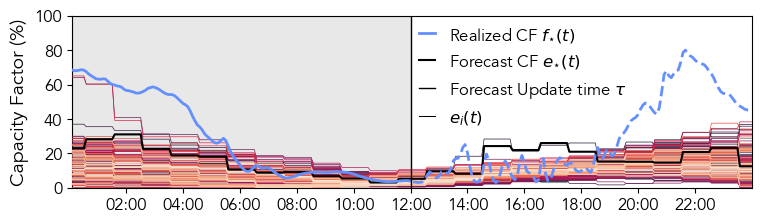

In [39]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_forecasts(
    _fig, 
    _ax, 
    palette_, 
    E_tr_biased_, 
    _fdu.w_fed_, 
    _fdu.idx_x_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    range_ = [0, 287],
    n = 120,
    legend_1 = True,
    legend_2 = True,
)

_ax.legend(
    loc = (0.5, 0.3125),
    frameon = False,
    fontsize = 12,
    ncol = 1,
)

plt.savefig(IMAGES / f"dayahead_neighbors-{file_name}.pdf")

plt.show()

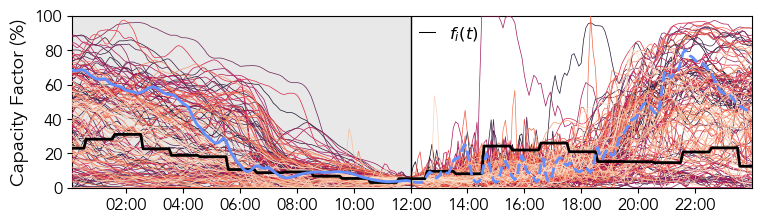

In [38]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_neighbors(
    _fig, 
    _ax, 
    palette_, 
    F_tr_, 
    _fdu.w_fed_, 
    _fdu.idx_x_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    range_ = [0, 287],
    legend_1 = T,
    legend_2 = False,
)

_ax.legend(
    loc = (0.5, 0.8),
    frameon = False,
    fontsize = 12,
    ncol = 1
)

plt.savefig(IMAGES / f"partial_neighbors-{file_name}.pdf")

plt.show()

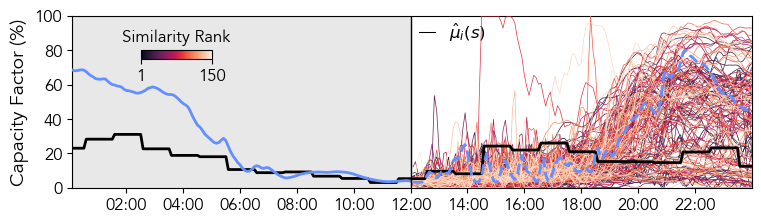

In [41]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_updates(
    _fig, 
    _ax, 
    palette_, 
    M_, 
    f_, 
    f_hat_, 
    e_biased_, 
    _fdu.w_fed_, 
    _fdu.idx_x_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    range_ = [0, 287],
    legend_1=True,
    legend_2=False,
)

_ax.legend(
    loc = (0.5, 0.8),
    frameon = False,
    fontsize = 12,
    ncol = 1
)

plt.savefig(IMAGES / f"dynamic_update_neighbors-{file_name}.pdf")

plt.show()

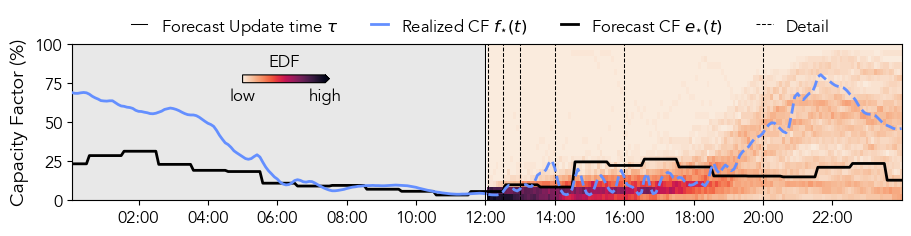

In [765]:
slices_ = [6, 12, 24, 48, 96]

_fig, _ax = plt.subplots(figsize=(9, 2.25), constrained_layout=True)

plotter.plot_heatmap_slices(
    _fig, 
    _ax, 
    palette_, 
    _fdu.M_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    slices_ = slices_,
    range_ = [0, 287],
    n = 120,
    colorbar = True,
)

_ax.legend(
    loc = (0.0625, 1), 
    frameon = False, 
    fontsize = 12, 
    ncol = 4
)

plt.savefig(IMAGES / f"heatmap-{file_name}.pdf")

plt.show()

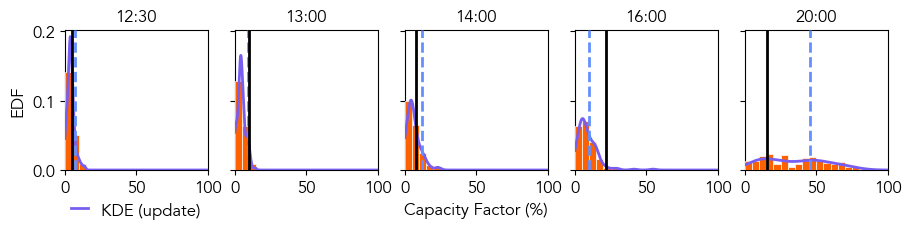

In [754]:
KDs_ = _fdu.weighted_kernel_density_estimation(
    100*M_, 
    weights = _fdu.w_fed_[_fdu.idx_x_local_],
    algorithm = "auto", 
    kernel = "gaussian"
)

_fig, _ax = plt.subplots(
    1, len(slices_), 
    figsize = (9, 2.25), 
    sharey = True, 
    layout = "constrained"
)

plotter.plot_histogram_cuts(
    _fig, 
    _ax, 
    palette_, 
    KDs_, 
    M_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_, 
    interval, 
    slices_ = slices_)

_ax[0].legend(
    frameon = False, 
    fontsize = 12, 
    loc = (0, -0.4)
)

plt.savefig(IMAGES / f"marginal_density_cutoffs-{file_name}.pdf")

plt.show()

In [571]:
F_curves_ = []
M_curves_ = []
D_curves_ = []
for interval in range(6, 282, 6):

    M_ = _fdu.predict(
        F_ts_[day, :interval, asset],
        E_ts_lin_[day, :, asset],
        X_ts_[asset, :],
        t_ts_[day],
        forget_rate_f = get_hyper(hyper_, "forget_rate_f", interval),
        forget_rate_e = get_hyper(hyper_, "forget_rate_e", interval),
        lookahead_rate = get_hyper(hyper_, "lookahead_rate", interval),
        length_scale_f = get_hyper(hyper_, "length_scale_f", interval),
        length_scale_e = get_hyper(hyper_, "length_scale_e", interval),
        length_scale_d = get_hyper(hyper_, "length_scale_d", interval),
        sigma = get_hyper(hyper_, "sigma", interval),
        nu = get_hyper(hyper_, "nu", interval),
        kappa_0 = get_hyper(hyper_, "kappa_0", interval),
        kappa = get_hyper(hyper_, "kappa", interval),
        p_fusion = get_hyper(hyper_, "p_fusion", interval),
    )

    # Compute depth to find the focal curve
    _F = FDataGrid(data_matrix=_fdu.M_, grid_points=_fdu.dt_[interval:])

    depth_rank_ = np.argsort(_depth(_F))[::-1]

    M_curves_.append(np.median(_fdu.M_, axis=0))
    F_curves_.append(_fdu.f_focal_)
    D_curves_.append(_fdu.M_[depth_rank_[0], :])

print(len(F_curves_), len(M_curves_), len(D_curves_))

46 46 46


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


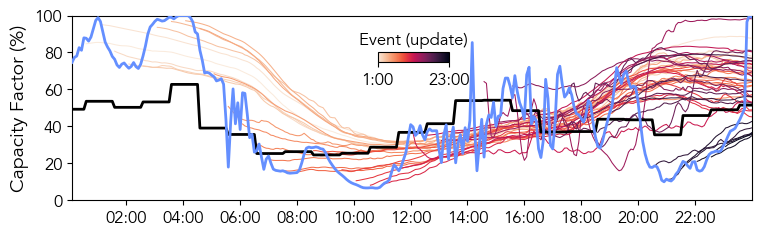

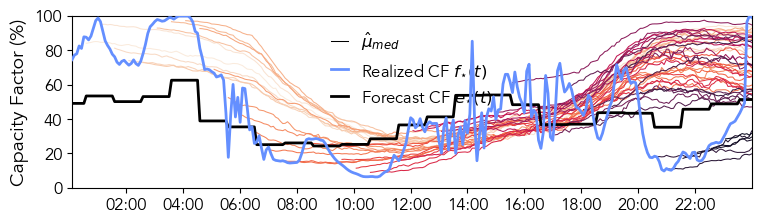

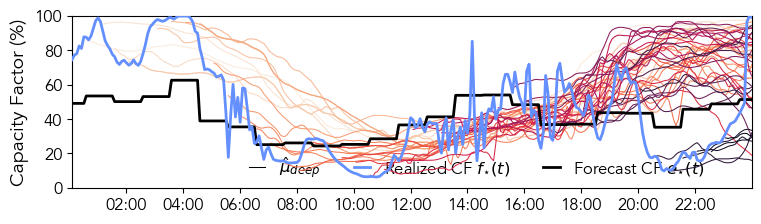

In [573]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_dynamic_update(
    _fig, _ax, palette_, 
    F_curves_, f_, f_hat_, e_biased_, dx_, dt_ + 5,
    label = r"$\hat{\mu}_{focal}$",
    range_ = [0, 287],
    legend = False,
    colorbar = True,
)

_ax.legend(
    loc = "upper center", 
    frameon = False, 
    fontsize = 12, 
    ncol = 3
)

plt.savefig(IMAGES / f"dynamic_update-focal_curve-{file_name}.pdf")

plt.show()

_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_dynamic_update(
    _fig, _ax, palette_, 
    M_curves_, f_, f_hat_, e_biased_, dx_, dt_ + 5, 
    range_ = [0, 287],
    legend = True,
    colorbar = False,
    label = r"$\hat{\mu}_{med}$"
)

_ax.legend(
    #loc = (0.25, -0.1), 
    frameon = False, 
    fontsize = 12, 
    ncol = 1
)

plt.savefig(IMAGES / f"dynamic_update-median_curve-{file_name}.pdf")

plt.show()

_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_dynamic_update(
    _fig, _ax, palette_, 
    D_curves_, f_, f_hat_, e_biased_, dx_, dt_ + 5, 
    range_ = [0, 287],
    legend = True,
    colorbar = False,
    label = r"$\hat{\mu}_{deep}$"
)

_ax.legend(
    loc = (0.25, 0.0), 
    frameon = False, 
    fontsize = 12, 
    ncol = 3
)

plt.savefig(IMAGES / f"dynamic_update-deepest_curve-{file_name}.pdf")

plt.show()

(67881,) (183,) (2019, 2) (183, 2)


 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:844: ShapelyDeprecationWarning:__len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:855: ShapelyDeprecationWarning:Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:850: ShapelyDeprecationWarning:__getitem__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
 <__array_function__ internals>:5: ShapelyDeprecationWarning:The array interface is deprecated and will

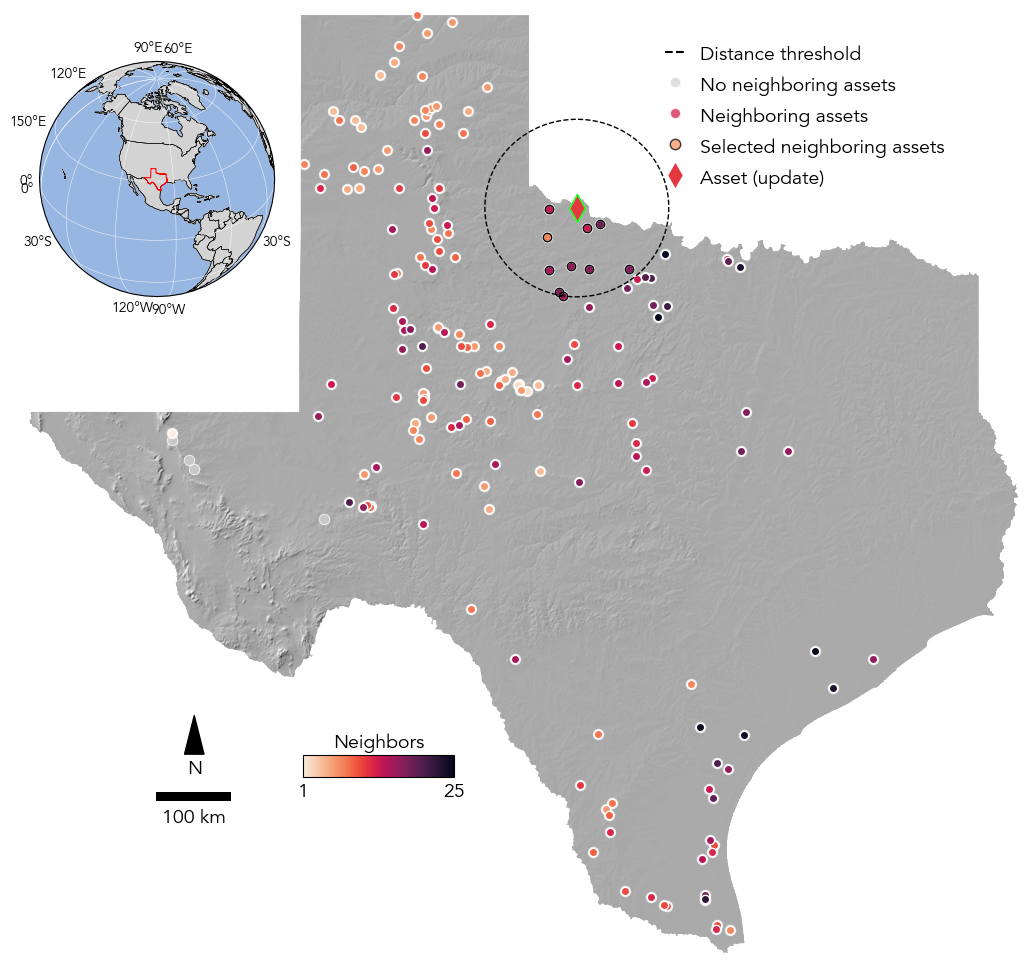

In [753]:
_fig, _ax = plt.subplots(1, 1, figsize=(10, 10), layout="constrained")

# Add an inset globe showing Texas
plotter.globe_inset(
    _fig, _ax, _TX, 
    x0 = 0.005, 
    y0 = 0.7, 
    width = 0.25, 
    height = 0.25
)

_fig, _ax = plotter.hillshade(_fig, _ax, _TX)

plotter.plot_hillshade_frequency_map(
    _fig, _ax, palette_, _TX, _fdu, X_tr_, X_ts_, 
    _fdu.x_, 
    _fdu.idx_fed_,
    _fdu.idx_x_, 
    _fdu.r,
)

# Add compass (North arrow)
x = 0.1675
y = 0.2575
arrow_length = 0.06  # relative axes coords

_ax.annotate(
    "N",
    xy = (x, y),
    xytext = (x, y - arrow_length),
    arrowprops = dict(facecolor = "k", 
                      arrowstyle = "wedge,tail_width=1,shrink_factor=.5"),
    ha = "center",
    va = "center",
    fontsize = 14,
    xycoords = _ax.transAxes,
)

scalebar = ScaleBar(
    dx = 100,  # scaling factor
    units = "km",
    dimension = "si-length",  # could also be 'imperial-length.'
    location = "lower left",
    length_fraction = 0.09,  # fraction of the axis for bar length
    color = "black",
    box_color = "None",
    box_alpha = 1.0,
    border_pad = 9,
    font_properties = {"size": 14},
)

_ax.add_artist(scalebar)

_ax.legend(
    frameon = False, 
    bbox_to_anchor = (0.625, 0.9875), 
    ncol = 1, 
    fontsize = 14
)

plt.savefig(IMAGES / f"hillshade_neighboring_assets-{file_name}.pdf")

plt.show()

(3600, 72)
-0.06983024691357997 0.11766975308641969
[ 0.11766975 -0.06358025 -0.02337963 -0.01304012  0.02716049  0.06180556
  0.01095679 -0.06983025 -0.06003086  0.01226852]


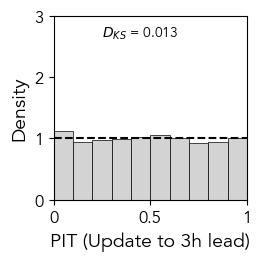

In [497]:
pit_ = loader.pit(
    _init, 
    resource, 
    method, 
    aggregation, 
    interval, 
    exp_description="unbiased-025",
    path_to_validation=VALIDATION
)

print(pit_.shape)

_fig, _ax = plt.subplots(
    figsize = (2.5, 2.5), 
    constrained_layout = True
)

lead = 0
bins = 10

plotter.plot_pit(
    _fig, _ax, pit_[:, lead*12:(lead + 3)*12].flatten(), 
    v = 0.4,
    bins = bins,
    xlabel = 'PIT (Update to 3h lead)'
)

plt.savefig(
    IMAGES / f"PIT-{resource}-{lead}-{bins}-{interval}.pdf"
)

plt.show()